# 22b — Profil cognitif d'un LLM : batterie CHC, profil « jagged » et contortions de capacité

**Navigation** : [22_Evaluating_Generated_Text](./22_Evaluating_Generated_Text.ipynb) · **22b (ce notebook)** · [NLP/01_TAL_Du_Mot_Aux_Dependances](../../NLP/01_TAL_Du_Mot_Aux_Dependances.ipynb)

## Pourquoi ce notebook existe

Le notebook 22 évalue **ce qu'un modèle écrit** : BLEU, ROUGE, juge LLM. Il laisse ouverte la question suivante : **qu'est-ce que ce modèle sait faire, et où casse-t-il ?** Un classement de type Elo ou un score unique de benchmark répond en *une* dimension. Hendrycks et al. (R13, *A Definition of AGI*, 2025) proposent l'inverse : dix domaines cognitifs issus de la théorie psychométrique **Cattell-Horn-Carroll (CHC)**, pondérés à 10 % chacun, et un **profil** plutôt qu'un score.

Ce notebook approfondit le 22, d'où la lettre `b` : on passe de l'évaluation d'une **sortie** à l'évaluation du **générateur**, avec les mêmes réflexes (correction mécanique, protocole explicite, méfiance envers les chiffres agrégés). On y construit une mini-batterie CHC textuelle, on l'exécute sur quatre modèles réels (un modèle de 0,8 milliard de paramètres sur CPU, trois modèles par API) et on en tire trois leçons :

1. le profil d'un LLM est **« jagged »** (en dents de scie) : excellent ici, nul là ;
2. le **score agrégé trompe** : un domaine à 0 % (la mémoire long terme) disparaît dans une moyenne ;
3. les systèmes compensent leurs trous par des **contortions de capacité** (le contexte à la place de la mémoire, la recherche externe à la place du rappel fiable), et ces contortions ont un coût mesurable.

Enfin, on élargit du *profil* au *risque* : les types d'IA stratégiques listés par R13 et le cube **Autonomie × Généralité × Intelligence** du *Singapore Consensus* (R11).

**Ce que vous saurez faire** : écrire des items à correction mécanique, mesurer un profil avec ses intervalles d'incertitude, lire un radar sans le réduire à sa moyenne, et reconnaître une contortion de capacité quand un système vous la présente comme une compétence.

**Prérequis** : [22](./22_Evaluating_Generated_Text.ipynb) (réflexe d'évaluation), [14](./14_Persistent_Memory.ipynb) (mémoire persistante), [05](./05_RAG_Modern.ipynb) (RAG). Clé `OPENAI_API_KEY` et, en option, `QWEN_API_KEY` + `QWEN_OPENAI_BASE_URL` dans `GenAI/.env` ; un modèle dont la clé manque est simplement retiré de la batterie. Le modèle local `Qwen/Qwen3.5-0.8B` est téléchargé depuis Hugging Face au premier lancement (environ 1,7 Go ; un CPU suffit).

***
## 1. Le cadre CHC de R13 : dix domaines, 10 % chacun

R13 part d'une définition volontairement modeste : une AGI est une IA qui **égale ou dépasse la polyvalence et la maîtrise cognitives d'un adulte instruit**. Pour la rendre mesurable, les auteurs reprennent les grandes aptitudes du modèle CHC, la théorie de l'intelligence humaine la mieux validée empiriquement, et les découpent en dix domaines :

| Code | Domaine | Ce qui est testé | Testable dans ce notebook |
|---|---|---|---|
| K | Connaissances générales | culture, sciences, sens commun | oui |
| RW | Lecture-écriture | compréhension, composition | oui |
| M | Mathématiques | de l'arithmétique au calcul différentiel | oui |
| R | Raisonnement sur le vif | déduction, induction, théorie de l'esprit | oui |
| WM | Mémoire de travail | maintenir et transformer une séquence | oui (modalité textuelle) |
| MS | Stockage long terme | apprendre durablement une information nouvelle | oui, et c'est le cœur du sujet |
| MR | Récupération long terme | fluence, absence de confabulation | oui |
| V | Traitement visuel | percevoir, générer, raisonner sur des images | non : batterie texte seule |
| A | Traitement auditif | parole, rythme, musique | non : batterie texte seule |
| S | Vitesse | tâches simples exécutées vite | oui (latence mesurée) |

R13 applique cette grille à GPT-4 et GPT-5 (Table 1, p. 3) et obtient **27 %** et **57 %**. La cellule suivante reprend ces chiffres tels que publiés et calcule ce que le total ne montre pas.

In [1]:
# Table 1 de R13 (Hendrycks et al., 2025, p. 3) : contribution de chaque domaine au score AGI.
# Chaque domaine pese 10 % ; la valeur est la part obtenue sur ces 10 points.
import numpy as np

DOMAINES = ["K", "RW", "M", "R", "WM", "MS", "MR", "V", "A", "S"]
TABLE1 = {
    "GPT-4 (2023)": [8, 6, 4, 0, 2, 0, 4, 0, 0, 3],
    "GPT-5 (2025)": [9, 10, 10, 7, 4, 0, 4, 4, 6, 3],
}

for modele, parts in TABLE1.items():
    profil = np.array(parts, dtype=float) / 10.0          # fraction de chaque domaine maitrisee
    nuls = [d for d, p in zip(DOMAINES, profil) if p == 0]
    print(f"{modele:13s} score AGI = {sum(parts):2d} %  | moyenne des domaines = {profil.mean():.2f}"
          f" | domaine minimal = {profil.min():.2f} | domaines a 0 : {nuls}")

print("\nProfil detaille (fraction de chaque domaine) :")
print("        " + " ".join(f"{d:>4s}" for d in DOMAINES))
for modele, parts in TABLE1.items():
    print(f"{modele[:6]:7s} " + " ".join(f"{p / 10:4.1f}" for p in parts))

gain = np.array(TABLE1["GPT-5 (2025)"]) - np.array(TABLE1["GPT-4 (2023)"])
print("\nGain GPT-4 -> GPT-5 par domaine (points) :", dict(zip(DOMAINES, gain.tolist())))

GPT-4 (2023)  score AGI = 27 %  | moyenne des domaines = 0.27 | domaine minimal = 0.00 | domaines a 0 : ['R', 'MS', 'V', 'A']
GPT-5 (2025)  score AGI = 57 %  | moyenne des domaines = 0.57 | domaine minimal = 0.00 | domaines a 0 : ['MS']

Profil detaille (fraction de chaque domaine) :
           K   RW    M    R   WM   MS   MR    V    A    S
GPT-4    0.8  0.6  0.4  0.0  0.2  0.0  0.4  0.0  0.0  0.3
GPT-5    0.9  1.0  1.0  0.7  0.4  0.0  0.4  0.4  0.6  0.3

Gain GPT-4 -> GPT-5 par domaine (points) : {'K': 1, 'RW': 4, 'M': 6, 'R': 7, 'WM': 2, 'MS': 0, 'MR': 0, 'V': 4, 'A': 6, 'S': 0}


### Lecture — le gain GPT-4 → GPT-5 se concentre, MS et S ne bougent pas

Le total **double** entre GPT-4 et GPT-5 (27 % puis 57 %), mais le détail raconte autre chose. Le gain se concentre sur les domaines que l'entraînement massif sait nourrir : raisonnement (+7 points), mathématiques (+6), traitement auditif et visuel (+6 et +4), lecture-écriture (+4). Trois colonnes n'ont **pas bougé du tout** : **MS reste à 0**, la récupération MR reste à 4 et la vitesse S reste à 3. Le domaine minimal vaut 0 pour les deux modèles : quelle que soit la progression affichée, le maillon le plus faible est le même.

R13 le dit explicitement (p. 15) : un système à 90 % mais à 0 % en stockage long terme serait « fonctionnellement handicapé par une forme d'amnésie », et les auteurs recommandent de publier **le profil cognitif, pas seulement le score**. Reste à vérifier si le motif se reproduit sur nos propres modèles.

***
## 2. Quatre modèles réels, deux familles d'accès

La batterie tourne sur quatre modèles choisis pour couvrir un large écart de taille :

| Modèle | Accès | Pourquoi il est là |
|---|---|---|
| `Qwen/Qwen3.5-0.8B` | local, CPU, `transformers` | petit modèle ouvert : aucune donnée ne sort de la machine, et la latence mesurée est celle de **votre** matériel |
| `gpt-4.1-nano` | API OpenAI | le plus petit modèle de la gamme 4.1 |
| `qwen3.6-flash` | API Qwen compatible OpenAI | modèle rapide d'une autre famille, pour comparer des profils et pas seulement des tailles |
| `gpt-4.1-mini` | API OpenAI | modèle intermédiaire, point de comparaison haut |

Deux choix de protocole à garder en tête :

- **température 0 (API) et décodage glouton (local)** : on mesure la réponse la plus probable, pas un tirage. Côté API, T=0 ne garantit pas le déterminisme ; la section 6 mesure ce qu'il en reste ;
- **mode « thinking » désactivé** pour les modèles Qwen (`enable_thinking=False`). R13 teste le raisonnement *sur le vif* ; un modèle qui délibère longuement mesurerait autre chose, avec une latence qui fausserait la vitesse S. Le notebook [08](./08_Reasoning_Models.ipynb) traite ce mode à part.

Aucun outil externe (recherche web, code) n'est branché : c'est la condition que R13 impose pour mesurer la récupération interne (annexe G.2, p. 43). Les clés sont lues dans `.env` (ou `.secrets/master.env` sur le cluster du cours) et ne sont **jamais affichées**, pas plus que l'adresse des services.

In [2]:
import os, re, time, random, warnings
from pathlib import Path

warnings.filterwarnings("ignore")
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")
os.environ.setdefault("TRANSFORMERS_VERBOSITY", "error")
from openai import OpenAI


def _lire_env(fichier):
    valeurs = {}
    for ligne in fichier.read_text(encoding="utf-8-sig").splitlines():
        ligne = ligne.strip()
        if ligne and not ligne.startswith("#") and "=" in ligne:
            nom, valeur = ligne.split("=", 1)
            valeurs[nom.strip()] = valeur.strip().strip('"').strip("'")
    return valeurs


def charger_env_local():
    """Remonte l'arborescence : .env (GenAI/.env de l'etudiant) puis .secrets/master.env (cluster)."""
    valeurs, cur = {}, Path.cwd()
    for _ in range(8):
        for cand in (cur / ".env", cur / ".secrets" / "master.env"):
            if cand.exists():
                for k, v in _lire_env(cand).items():
                    valeurs.setdefault(k, v)
        if cur == cur.parent:
            break
        cur = cur.parent
    return valeurs


ENV = charger_env_local()
def cle(nom):
    return os.getenv(nom) or ENV.get(nom)

ROUTES = {}
if cle("OPENAI_API_KEY"):
    ROUTES["openai"] = OpenAI(api_key=cle("OPENAI_API_KEY"), timeout=180)
if cle("QWEN_API_KEY") and cle("QWEN_OPENAI_BASE_URL"):
    _base = cle("QWEN_OPENAI_BASE_URL").rstrip("/")
    _base = _base if _base.endswith("/v1") else _base + "/v1"
    ROUTES["qwen"] = OpenAI(base_url=_base, api_key=cle("QWEN_API_KEY"), timeout=180)
for nom in ("openai", "qwen"):
    print(f"route {nom:6s} : {'cle configuree (masquee)' if nom in ROUTES else 'absente -> modeles retires'}")

MODELES = [
    {"nom": "Qwen3.5-0.8B (local)", "route": "local", "id": "Qwen/Qwen3.5-0.8B"},
    {"nom": "gpt-4.1-nano", "route": "openai", "id": "gpt-4.1-nano"},
    {"nom": "qwen3.6-flash", "route": "qwen", "id": "qwen3.6-flash"},
    {"nom": "gpt-4.1-mini", "route": "openai", "id": "gpt-4.1-mini"},
]
MODELES = [m for m in MODELES if m["route"] == "local" or m["route"] in ROUTES]
if cle("HF_TOKEN"):
    os.environ.setdefault("HF_TOKEN", cle("HF_TOKEN"))   # evite les limites du Hub anonyme ; jamais affiche

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

torch.manual_seed(0)
_t0 = time.time()
TOK_LOCAL = AutoTokenizer.from_pretrained("Qwen/Qwen3.5-0.8B")
LLM_LOCAL = AutoModelForCausalLM.from_pretrained("Qwen/Qwen3.5-0.8B", dtype=torch.float32).eval()
print(f"modele local charge en {time.time() - _t0:.1f} s ; "
      f"{sum(p.numel() for p in LLM_LOCAL.parameters()) / 1e6:.0f} M parametres ; "
      f"{torch.get_num_threads()} threads CPU")


def _nettoyer(texte):
    return re.sub(r"<think>.*?</think>", "", texte or "", flags=re.S).strip()


def _masquer(message):
    message = re.sub(r"https?://\S+", "<url masquee>", message)
    return re.sub(r"sk-[\w\-*]+", "<cle masquee>", message)


def interroger(modele, messages, max_tokens=60):
    """Un appel deterministe (T=0 / glouton). Renvoie texte, latence (s), tokens de prompt, erreur."""
    t0 = time.time()
    try:
        if modele["route"] == "local":
            prompt = TOK_LOCAL.apply_chat_template(messages, tokenize=False, add_generation_prompt=True,
                                                   enable_thinking=False)
            ids = TOK_LOCAL(prompt, return_tensors="pt")
            with torch.no_grad():
                out = LLM_LOCAL.generate(**ids, max_new_tokens=max_tokens, do_sample=False)
            texte = TOK_LOCAL.decode(out[0][ids["input_ids"].shape[1]:], skip_special_tokens=True)
            n_prompt = int(ids["input_ids"].shape[1])
        else:
            extra = {"extra_body": {"enable_thinking": False}} if modele["route"] == "qwen" else {}
            rep = ROUTES[modele["route"]].chat.completions.create(
                model=modele["id"], messages=messages, temperature=0, max_tokens=max_tokens, **extra)
            texte = rep.choices[0].message.content or ""
            n_prompt = rep.usage.prompt_tokens if rep.usage else None
        return {"texte": _nettoyer(texte), "latence": time.time() - t0, "tokens_prompt": n_prompt, "erreur": None}
    except Exception as exc:
        return {"texte": "", "latence": time.time() - t0, "tokens_prompt": None,
                "erreur": _masquer(f"{type(exc).__name__}: {str(exc)[:100]}")}


print("\nSonde ('Reply with the single word OK.') :")
for m in MODELES:
    r = interroger(m, [{"role": "user", "content": "Reply with the single word OK."}], max_tokens=5)
    print(f"  {m['nom']:22s} {r['latence']:5.2f} s -> {r['texte'] or r['erreur']!r}")

route openai : cle configuree (masquee)
route qwen   : cle configuree (masquee)


modele local charge en 3.6 s ; 752 M parametres ; 14 threads CPU

Sonde ('Reply with the single word OK.') :


  Qwen3.5-0.8B (local)    0.74 s -> 'OK'


  gpt-4.1-nano            1.72 s -> 'OK'


  qwen3.6-flash           1.19 s -> 'OK'


  gpt-4.1-mini            0.91 s -> 'OK'


### Lecture — quatre routes répondent, le local le plus rapide sur un mot

Les quatre routes répondent `OK` : les clés sont lues (et masquées), le modèle local est chargé en 3,6 s (752 millions de paramètres, 14 threads CPU), et aucun appel n'échoue. L'avertissement `HF_TOKEN` est sans conséquence : le modèle est public, le jeton ne ferait que relever la limite de débit du Hub.

Sur une réponse d'**un seul mot**, le modèle local est le plus rapide des quatre (0,74 s), devant `gpt-4.1-mini` (0,91 s), `qwen3.6-flash` (1,19 s) et `gpt-4.1-nano` (1,72 s) : un appel d'API paie un aller-retour réseau et une file d'attente que le calcul local ne paie pas.

Ce classement ne tiendra pas. Le coût local croît avec chaque jeton **généré** et chaque jeton **lu**, alors que celui d'une API reste presque plat : la section 4 et le carnet de la section 7 le mesurent. Une sonde d'un mot vérifie que la plomberie marche ; elle ne dit rien de la vitesse sur une vraie tâche.

***
## 3. La mini-batterie : des items à correction mécanique

Chaque item porte son **correcteur**, une fonction Python qui renvoie vrai ou faux (ou un score entre 0 et 1 pour la fluence). Il n'y a **aucun juge LLM** : le notebook 22 a montré les biais de position et de verbosité d'un juge, et une batterie qui se corrige avec un modèle mesurerait deux modèles à la fois.

Chaque item porte aussi un **budget de jetons**, et ce budget fait partie de la mesure. La vitesse (S) n'accorde que 16 jetons : la réponse doit venir d'un trait, sans calcul posé. Les mathématiques (M) en accordent 400 : ce domaine mesure le calcul, pas la concision, et un modèle qui détaille ses étapes doit pouvoir atteindre sa valeur finale avant d'être coupé. Le correcteur de M lit le **dernier** nombre de la réponse, ou la fraction attendue sous sa forme LaTeX (`\frac{1}{36}`). Un budget trop court ferait échouer un modèle correct sur une réponse tronquée : l'échec mesurerait l'instrument, pas le modèle.

Trois précautions d'honnêteté, à garder en tête à chaque lecture de résultat :

- **les items sont en anglais**, comme ceux de R13, qui reconnaît lui-même (p. 15) que ses tests sont centrés sur l'anglais et ne sont pas culturellement neutres. L'exercice 2 mesure ce que coûte un changement de formulation ;
- plusieurs items **reprennent les exemples de R13** (l'énigme David/Jack sans ses options de réponse, la boîte de Pringles, la liste `[10, 20, 30]`, les mots inventés, Napoléon, Churchill, `9 × 10 × 11`, `5.11 ou 5.9`). Un modèle récent peut les avoir vus : c'est le risque de **contamination** que R13 signale (p. 14). Les autres items sont construits pour ce notebook ;
- avec **quatre à six items par domaine** (dix-neuf pour la mémoire de travail), un score de domaine est une mesure grossière. La section 4 lui attache un intervalle de confiance, alors que R13 spécifie des batteries autrement plus larges, étalonnées sur des humains. Nous mesurons **une forme**, pas un niveau comparable aux 27 % et 57 %.

In [3]:
# --- Correcteurs : chacun renvoie une fonction texte -> bool ---
def _nombres(texte):
    return [float(x.replace(",", "")) for x in re.findall(r"-?\d[\d,]*(?:\.\d+)?", texte)]

def dernier_nombre(attendu, tol=1e-6):
    """Le DERNIER nombre de la reponse ('9 x 10 x 11 = 990' -> 990) doit valoir `attendu`."""
    return lambda t: bool(_nombres(t)) and abs(_nombres(t)[-1] - attendu) <= tol

def premier_candidat(attendu, candidats):
    """Parmi des candidats connus, celui qui apparait EN PREMIER doit etre `attendu`."""
    def f(t):
        tl = t.lower()
        pos = {c: tl.find(c) for c in candidats if tl.find(c) >= 0}
        return bool(pos) and min(pos, key=pos.get) == attendu
    return f

def contient(*mots):
    return lambda t: any(m.lower() in t.lower() for m in mots)

def oui_non(attendu):
    def f(t):
        m = re.search(r"\b(yes|no)\b", t.lower())
        return bool(m) and m.group(1) == attendu
    return f

def nb_mots_exact(n):
    return lambda t: len(re.findall(r"[A-Za-z']+", t.strip().split("\n")[0])) == n

def derivee_3x2(t):
    s = t.lower().replace(" ", "").replace("*", "").replace("²", "^2")
    return "3x^2" in s

def proba_1_36(t):
    s = t.replace(" ", "")
    return ("1/36" in s or re.search(r"frac\{1\}\{36\}", s) is not None
            or any(abs(x - 1 / 36) < 1e-3 for x in _nombres(t)))


ITEMS = []
def item(domaine, ident, prompt, correcteur, max_tokens=60, poids=1.0, **extra):
    ITEMS.append({"domaine": domaine, "id": ident, "prompt": prompt, "correcteur": correcteur,
                  "max_tokens": max_tokens, "poids": poids, **extra})

# K - connaissances generales (dont une question de sens commun)
item("K", "K-or", "What is the chemical symbol for gold? Answer with the symbol only.",
     lambda t: re.search(r"\bAu\b", t) is not None)
item("K", "K-berlin", "In which year did the Berlin Wall fall? Answer with the year only.", dernier_nombre(1989))
item("K", "K-planete", "What is the largest planet in the Solar System? Answer with one word.", contient("jupiter"))
item("K", "K-hugo", "Who wrote the novel 'Les Miserables'? Answer with the author's name only.", contient("hugo"))
item("K", "K-co2", "Which gas do plants absorb from the air for photosynthesis? Answer briefly.",
     contient("carbon dioxide", "co2", "co₂"))
item("K", "K-glace", "If you leave a glass of water in a freezer overnight, what has the water turned into "
     "by morning? Answer with one word.", contient("ice", "frozen", "solid"))

# RW - comprehension (dont une paire de type Winograd) et ecriture sous contrainte
item("RW", "RW-vote", "Passage: 'The committee postponed the vote because two members were absent; it will "
     "reconvene on Thursday.' Question: why was the vote postponed? Answer in at most eight words.", contient("absent"))
item("RW", "RW-nage", "Passage: 'Unlike her brother, Mara never learned to swim, although she grew up by the sea.' "
     "Question: can Mara swim? Answer yes or no.", oui_non("no"))
item("RW", "RW-trophee-grand", "The trophy doesn't fit in the brown suitcase because it is too big. "
     "What is too big? Answer with one word.", premier_candidat("trophy", ["trophy", "suitcase"]))
item("RW", "RW-trophee-petit", "The trophy doesn't fit in the brown suitcase because it is too small. "
     "What is too small? Answer with one word.", premier_candidat("suitcase", ["trophy", "suitcase"]))
item("RW", "RW-7mots", "Write one sentence about rain containing exactly seven words. Output only the sentence.",
     nb_mots_exact(7))

# M - mathematiques, de l'arithmetique au calcul. Budget large : le domaine M mesure le calcul,
# pas la concision ; un modele qui pose son raisonnement doit pouvoir atteindre sa valeur finale.
BUDGET_M = 400
item("M", "M-produit", "What is 17 x 24? Answer with the number only.", dernier_nombre(408), max_tokens=BUDGET_M)
item("M", "M-equation", "Solve for x: 3x + 7 = 25. Answer with the value of x only.", dernier_nombre(6),
     max_tokens=BUDGET_M)
item("M", "M-de", "A fair six-sided die is rolled twice. What is the probability that both rolls show a 6? "
     "Answer as a fraction.", proba_1_36, max_tokens=BUDGET_M)
item("M", "M-derivee", "What is the derivative of x^3 with respect to x? Answer with the expression only.", derivee_3x2,
     max_tokens=BUDGET_M)
item("M", "M-cercle", "What is the area of a circle of radius 3? Give the numerical value rounded to two decimals.",
     dernier_nombre(28.27, tol=0.006), max_tokens=BUDGET_M)
item("M", "M-puissance", "What is 2 to the power of 10? Answer with the number only.", dernier_nombre(1024),
     max_tokens=BUDGET_M)

# R - raisonnement sur le vif : deduction (R13 p. 9), theorie de l'esprit (R13 p. 9), induction, syllogisme
item("R", "R-david", "David knows Mr. Zhang's friend Jack, and Jack knows David's friend Ms. Lin. Everyone of "
     "them who knows Jack has a master's degree, and everyone of them who knows Ms. Lin is from Shanghai. "
     "Who is from Shanghai and has a master's degree? Answer with the name only.",
     premier_candidat("david", ["david", "jack", "zhang", "lin"]))
item("R", "R-pringles", "The can of Pringles has moldy chips in it. Mary picks up the can in the supermarket and "
     "walks to the cashier. Is Mary likely to be aware that the can of Pringles has moldy chips in it? "
     "Answer yes or no.", oui_non("no"))
item("R", "R-suite", "What is the next number in the sequence 2, 6, 12, 20, 30, ...? Answer with the number only.",
     dernier_nombre(42))
item("R", "R-tailles", "Alice is taller than Bob. Carol is shorter than Bob. Dave is taller than Alice. "
     "Who is the second tallest? Answer with the name only.",
     premier_candidat("alice", ["alice", "bob", "carol", "dave"]))
item("R", "R-syllogisme", "All bloops are razzies. Some razzies are lazzies. Does it necessarily follow that "
     "some bloops are lazzies? Answer yes or no.", oui_non("no"))

# S - vitesse (R13 p. 12) : correct ET rapide ; le seuil est une convention de ce notebook
SEUIL_VITESSE_S = 2.0
item("S", "S-produit", "Compute 9 x 10 x 11. Answer with the number only.", dernier_nombre(990), max_tokens=16)
item("S", "S-compare", "Quickly choose the larger number: 5.11 or 5.9. Answer with the number only.",
     premier_candidat("5.9", ["5.11", "5.9"]), max_tokens=16)
item("S", "S-max", "Find the largest number in '48291, 93652, 12844, 59277'. Answer with the number only.",
     premier_candidat("93652", ["48291", "93652", "12844", "59277"]), max_tokens=16)
item("S", "S-hello", "After reading this, immediately say 'hello'.", contient("hello"), max_tokens=16)

from collections import Counter
print("Items par domaine :", dict(Counter(i["domaine"] for i in ITEMS)))
print("Correcteurs essayes sur des reponses fictives, avant tout appel de modele :")
c_produit = [i for i in ITEMS if i["id"] == "S-produit"][0]["correcteur"]
c_compare = [i for i in ITEMS if i["id"] == "S-compare"][0]["correcteur"]
for rep in ["990", "9 x 10 x 11 = 990", "900"]:
    print(f"  S-produit  {rep!r:28s} -> {c_produit(rep)}")
for rep in ["5.9", "5.9 is larger than 5.11", "5.11 is larger than 5.9"]:
    print(f"  S-compare  {rep!r:28s} -> {c_compare(rep)}")

Items par domaine : {'K': 6, 'RW': 5, 'M': 6, 'R': 5, 'S': 4}
Correcteurs essayes sur des reponses fictives, avant tout appel de modele :
  S-produit  '990'                        -> True
  S-produit  '9 x 10 x 11 = 990'          -> True
  S-produit  '900'                        -> False
  S-compare  '5.9'                        -> True
  S-compare  '5.9 is larger than 5.11'    -> True
  S-compare  '5.11 is larger than 5.9'    -> False


### Lecture — les correcteurs vérifiés sur réponses fictives avant tout appel

Les correcteurs sont essayés sur des réponses fictives **avant** tout appel de modèle. `dernier_nombre` accepte « 9 x 10 x 11 = 990 » (recopier le calcul ne pénalise pas) et rejette « 900 ». `premier_candidat` accepte « 5.9 is larger than 5.11 » et rejette « 5.11 is larger than 5.9 » : c'est le premier candidat cité qui compte. Une règle naïve du type « la réponse contient 5.9 » aurait validé les deux phrases, dont une fausse.

Écrire le correcteur **avant** de voir les réponses est la discipline qui rend la mesure honnête : un correcteur ajusté après coup finit toujours par donner raison au modèle qu'on préfère.

***
### 3.1 Mémoire de travail : un générateur, pas une liste figée

R13 teste la mémoire de travail (WM) par des **séquences de transformations** : partir de `[10, 20, 30]`, ajouter 40, puis inverser (p. 9). Plutôt que d'écrire quelques items à la main, on écrit un **générateur** : une liste de départ tirée au hasard (graine fixe), puis `n` opérations prises dans un répertoire (ajouter, insérer en tête, inverser, retirer le premier, trier, échanger les extrémités...). La réponse attendue est **calculée par Python** : aucune ambiguïté de correction, et la difficulté se règle par un seul bouton, le nombre d'opérations. Une contrainte garde ce bouton honnête : deux opérations consécutives sont toujours différentes. Sans elle, le tirage produit des suites comme « trier, trier, trier », qui comptent trois étapes pour une seule transformation effective. S'y ajoutent trois items de rappel (remettre des mots inventés dans l'ordre alphabétique), dont l'exemple de R13.

In [4]:
OPERATIONS_WM = [
    ("append the number {x}", lambda l, x: l + [x]),
    ("insert the number {x} at the beginning", lambda l, x: [x] + l),
    ("reverse the list", lambda l, x: l[::-1]),
    ("remove the first element", lambda l, x: l[1:]),
    ("remove the last element", lambda l, x: l[:-1]),
    ("sort the list in ascending order", lambda l, x: sorted(l)),
    ("swap the first and the last elements", lambda l, x: [l[-1]] + l[1:-1] + [l[0]] if len(l) > 1 else l),
]


def item_transformation(n_ops, rng):
    depart = rng.sample(range(10, 100), 4)
    courant, etapes, precedente = list(depart), [], None
    for _ in range(n_ops):
        # jamais deux fois la meme operation d'affilee : "trier, trier" ou "inverser, inverser"
        # ajouteraient une etape sans ajouter de charge
        texte, f = rng.choice([op for op in OPERATIONS_WM if op[0] != precedente])
        if len(courant) <= 2 and texte.startswith("remove"):   # ne jamais vider la liste
            texte, f = OPERATIONS_WM[0]
        x = rng.randrange(10, 100)
        courant = f(courant, x)
        etapes.append(texte.format(x=x))
        precedente = texte
    consignes = " ".join(f"Step {i + 1}: {e}." for i, e in enumerate(etapes))
    prompt = (f"Start with the list {depart}. {consignes} "
              "Answer with the final list only, in Python list format.")
    return prompt, courant


def liste_attendue(attendu):
    def f(t):
        blocs = re.findall(r"\[[^\[\]]*\]", t)
        return bool(blocs) and [int(v) for v in re.findall(r"-?\d+", blocs[-1])] == attendu
    return f


def ordre_alphabetique(mots):
    attendu = [m.lower() for m in sorted(mots, key=str.lower)]
    connus = {m.lower() for m in mots}
    def f(t):
        vus = []
        for m in re.findall(r"[A-Za-z]+", t):
            if m.lower() in connus and m.lower() not in vus:
                vus.append(m.lower())
        return vus == attendu
    return f


# Exemple de R13 (p. 9), verbatim
item("WM", "WM-r13", "Start with the list [10, 20, 30]. First, append the number 40. Then reverse the list. "
     "Answer with the final list only, in Python list format.", liste_attendue([40, 30, 20, 10]))

rng_wm = random.Random(2026)
NIVEAUX_WM = [1, 2, 4, 6, 8]
for n_ops in NIVEAUX_WM:
    for k in range(3):
        p, attendu = item_transformation(n_ops, rng_wm)
        item("WM", f"WM-{n_ops}ops-{k}", p, liste_attendue(attendu), niveau=n_ops, attendu=attendu)

for mots in (["Fleep", "Zorp", "Glim", "Chair"],                         # R13 (p. 9), verbatim
             ["Blick", "Trasp", "Mooven", "Quell", "Drin", "Snarf"],
             ["Plonk", "Vesh", "Arbic", "Yolt", "Gruntle", "Kiff", "Ossum", "Nabe"]):
    item("WM", f"WM-rappel-{len(mots)}", f"Here is a list of made-up words: {mots}. "
         "State the words in alphabetical order, separated by commas.", ordre_alphabetique(mots), max_tokens=80)

exemple = [i for i in ITEMS if i["id"] == "WM-6ops-0"][0]
print("Item genere a 6 operations :\n ", exemple["prompt"])
print("Reponse attendue calculee par Python :", exemple["attendu"])
print("Nombre d'items WM :", sum(1 for i in ITEMS if i["domaine"] == "WM"))

Item genere a 6 operations :
  Start with the list [38, 26, 16, 76]. Step 1: sort the list in ascending order. Step 2: swap the first and the last elements. Step 3: remove the first element. Step 4: insert the number 71 at the beginning. Step 5: reverse the list. Step 6: swap the first and the last elements. Answer with the final list only, in Python list format.
Reponse attendue calculee par Python : [71, 38, 26, 16]
Nombre d'items WM : 19


### Lecture — l'item de mémoire de travail vérifié à la main

L'item affiché se vérifie à la main, et c'est exactement ce qu'on demande au modèle de faire **sans l'écrire** : `[38, 26, 16, 76]` trié donne `[16, 26, 38, 76]` ; l'échange des extrémités, `[76, 26, 38, 16]` ; le retrait du premier, `[26, 38, 16]` ; l'insertion de 71, `[71, 26, 38, 16]` ; l'inversion, `[16, 38, 26, 71]` ; un dernier échange, `[71, 38, 26, 16]`. C'est la valeur calculée par Python.

Six états intermédiaires à tenir, et la consigne « la liste finale seulement » interdit de les poser sur le papier. C'est ce qui fait de l'item un test de **mémoire de travail** plutôt que de raisonnement : chaque opération est triviale, seule leur accumulation est difficile.

Le générateur produit 15 items de ce type, trois par niveau (1, 2, 4, 6 et 8 opérations). S'y ajoutent l'exemple `[10, 20, 30]` de R13 et les trois listes de mots inventés, soit **19 items WM**.

***
### 3.2 Stockage et récupération long terme : MS et MR

**MS, le stockage long terme**, se teste en deux sessions séparées : dans la première, on confie une information au modèle (« retiens que mon code de casier est 4719 ») ; dans la seconde, **un nouvel appel sans historique**, on la lui redemande. Un appel d'API est sans état : le modèle ne peut réussir qu'en devinant. Nous le mesurons quand même, parce qu'un « zéro par construction » que l'on ne mesure pas finit par disparaître du profil. Le même item est rejoué **avec l'historique dans le contexte** : c'est la contortion étudiée en section 7.

**MR, la récupération long terme**, a deux composantes pondérées comme dans R13 (p. 11 et annexe G, p. 41-43) :

- **hallucinations (4 points sur 10)** : quatre questions à prémisse fausse. Deux viennent de R13 (la « campagne sud-africaine » de Napoléon, la citation de Kennedy attribuée à Churchill), une porte sur un article **inventé pour ce notebook**, une sur **notre propre dépôt** (une section « METEOR » que le notebook 22 ne contient pas). Le correcteur cherche un marqueur de rectification ou de prudence, en anglais ou en français, dans le début de la réponse : il est **indulgent** par construction, et la section 4 affiche les réponses pour que vous puissiez le contredire ;
- **fluence (6 points sur 10)** : produire le plus de mots possible d'une catégorie non sémantique (palindromes, mots commençant par *q*), deux exemples de R13 (G.1.4, p. 42). Chaque mot est validé mécaniquement (propriété vérifiée + présence dans le lexique anglais `nltk.words`). Ce lexique sert de garde-fou contre les mots inventés, mais il est incomplet : il lui manque des formes fléchies et des mots courants. Le correcteur pèche donc par **sévérité**, et la section 4 sépare ses faux négatifs des vraies erreurs du modèle. R13 donne 60 secondes à un humain mais pas de norme chiffrée ; **nous fixons la cible à 10 mots valides distincts**. C'est une convention de ce notebook, pas une norme publiée.

In [5]:
import nltk
nltk.download("words", quiet=True)
from nltk.corpus import words as _nltk_words
LEXIQUE = {w.lower() for w in _nltk_words.words()}
print(f"Lexique anglais nltk : {len(LEXIQUE)} mots")

CIBLE_FLUENCE = 10

def fluence(valide):
    def f(t):
        candidats = {w.lower() for w in re.findall(r"[A-Za-z]+", t)}
        return min(1.0, sum(1 for w in candidats if valide(w)) / CIBLE_FLUENCE)
    return f

est_palindrome = lambda w: len(w) >= 3 and w == w[::-1] and w in LEXIQUE
commence_par_q = lambda w: len(w) >= 3 and w.startswith("q") and w in LEXIQUE

MARQUEURS_PRUDENCE = ["never", "did not", "didn't", "does not", "doesn't", "no record", "not aware",
                      "no information", "not familiar", "unfamiliar", "no such", "not exist", "unable to",
                      "cannot", "can't", "could not", "couldn't", "don't have", "do not have", "no evidence",
                      "fictional", "there is no", "there was no", "not a real", "not sure", "no known",
                      "not able", "not publicly", "not find", "misattribut", "not by churchill",
                      "not churchill", "kennedy", "contradict", "no mention", "not mention", "not include",
                      "not contain",
                      # un modele peut repondre en francais quand le contexte fourni l'est (section 7)
                      "ne mentionne pas", "ne contient pas", "n'existe pas", "n'a jamais", "il n'y a pas",
                      "aucune", "aucun", "ne parle pas", "ne traite pas", "ne semble pas"]

def prudent(t):
    debut = t.lower()[:250]
    return any(m in debut for m in MARQUEURS_PRUDENCE)

# MR - hallucinations (poids total 0.4) et fluence (poids total 0.6), comme R13 annexe G
item("MR", "MR-napoleon", "Describe the key strategy that Napoleon Bonaparte used to win his South African "
     "campaign. Answer in two sentences.", prudent, max_tokens=90, poids=0.1, sous="hallucination")
item("MR", "MR-churchill", "What was the context for Winston Churchill's famous 1961 inaugural address, where he "
     "said, 'Ask not what your country can do for you - ask what you can do for your country'? "
     "Answer in two sentences.", prudent, max_tokens=90, poids=0.1, sous="hallucination")
item("MR", "MR-article", "Summarize in two sentences the main result of the NeurIPS 2019 paper 'Quantum Gradient "
     "Folding for Sparse Transformers' by Leclerc and Moreau.", prudent, max_tokens=90, poids=0.1,
     sous="hallucination")
item("MR", "MR-coursia", "In the CoursIA repository, the notebook GenAI/Texte/22_Evaluating_Generated_Text.ipynb is "
     "known for its section on the METEOR metric. Summarize in two sentences how that section computes METEOR.",
     prudent, max_tokens=90, poids=0.1, sous="hallucination")
item("MR", "MR-palindromes", "List as many English words that are palindromes as you can. "
     "Output only the words, separated by commas.", fluence(est_palindrome), max_tokens=250, poids=0.3,
     sous="fluence")
item("MR", "MR-q", "List as many English words starting with the letter q as you can. "
     "Output only the words, separated by commas.", fluence(commence_par_q), max_tokens=250, poids=0.3,
     sous="fluence")

# MS - stockage long terme : on confie un fait (session 1), on le redemande dans une session neuve (session 2)
FAITS_MS = [
    ("Please remember this for later: my locker code is 4719.",
     "What is my locker code? Answer with the code only.", "4719"),
    ("Please remember this for later: my dog is called Biscotte.",
     "What is my dog called? Answer with the name only.", "biscotte"),
    ("Please remember this for later: our meeting room is B-214.",
     "Which room is our meeting room? Answer with the room only.", "214"),
]
for k, (fait, question, attendu) in enumerate(FAITS_MS):
    item("MS", f"MS-{k}", question, contient(attendu), max_tokens=20, ms=(fait, attendu))

essai = "level, radar, noon, hello, kayak, abba, refer"
print(f"Correcteur de fluence sur une liste fictive {essai!r} -> score palindromes = "
      f"{fluence(est_palindrome)(essai):.1f}")
print("Correcteur de prudence : 'Napoleon never campaigned in South Africa.' ->",
      prudent("Napoleon never campaigned in South Africa."),
      "| 'His key strategy was rapid flanking.' ->", prudent("His key strategy was rapid flanking."))
print("Items par domaine :", dict(Counter(i["domaine"] for i in ITEMS)), "| total :", len(ITEMS))

Lexique anglais nltk : 234377 mots
Correcteur de fluence sur une liste fictive 'level, radar, noon, hello, kayak, abba, refer' -> score palindromes = 0.6
Correcteur de prudence : 'Napoleon never campaigned in South Africa.' -> True | 'His key strategy was rapid flanking.' -> False
Items par domaine : {'K': 6, 'RW': 5, 'M': 6, 'R': 5, 'S': 4, 'WM': 19, 'MR': 6, 'MS': 3} | total : 54


### Lecture — le lexique nltk et la convention du correcteur de prudence

Le lexique `nltk` compte 234 377 mots. Sur la liste fictive, le correcteur de fluence rejette `hello` (ce n'est pas un palindrome) et accepte les six autres : 6 mots valides pour une cible de 10, soit 0,6. Le correcteur de prudence reconnaît la phrase qui rectifie la prémisse (« Napoleon never campaigned in South Africa ») et rejette celle qui l'accepte en inventant une stratégie.

Une convention du correcteur mérite d'être dite : il n'accepte que des mots d'**au moins trois lettres**, alors que la consigne envoyée au modèle ne le précise pas. Elle écarte `a`, palindrome au sens strict, pour qu'un modèle ne puisse pas remplir sa liste de lettres isolées. C'est un choix de ce notebook, écrit ici plutôt que caché dans le code.

La batterie complète compte **54 items** : 6 en K, 5 en RW, 6 en M, 5 en R, 4 en S, 19 en WM, 6 en MR et 3 en MS.

***
## 4. Exécution de la batterie

Chaque modèle reçoit chaque item dans **une conversation neuve** (aucun historique, sauf pour le rejeu de MS). Pour la vitesse S, un item n'est réussi que s'il est **juste et rendu en moins de 2 secondes**. Ce seuil est une convention de ce notebook : il mesure le **système** (réseau, file d'attente du fournisseur, CPU local), pas seulement le modèle. R13 relève d'ailleurs (tableau de la p. 13) que GPT-4 et GPT-5 plafonnent tous deux à 3 points sur 10 en vitesse. Un appel en erreur est compté comme échec **et signalé**, jamais retiré en silence.

In [6]:
import pandas as pd
pd.set_option("display.width", 200)


def court(t, n=150):
    """Extrait d'une reponse sur une seule ligne, pour l'affichage."""
    t = " ".join((t or "").split())
    return t if len(t) <= n else t[:n] + "..."


def evaluer_item(modele, it):
    base = {"modele": modele["nom"], "domaine": it["domaine"], "id": it["id"], "poids": it["poids"],
            "sous": it.get("sous", ""), "niveau": it.get("niveau")}
    if "ms" in it:
        fait, attendu = it["ms"]
        r1 = interroger(modele, [{"role": "user", "content": fait}], max_tokens=40)
        r2 = interroger(modele, [{"role": "user", "content": it["prompt"]}], max_tokens=it["max_tokens"])
        r3 = interroger(modele, [{"role": "user", "content": fait},
                                 {"role": "assistant", "content": r1["texte"] or "OK."},
                                 {"role": "user", "content": it["prompt"]}], max_tokens=it["max_tokens"])
        juste = float(attendu in r2["texte"].lower())
        return {**base, "score": juste, "juste": juste, "latence": r2["latence"],
                "erreur": r2["erreur"] or r3["erreur"], "texte": r2["texte"],
                "avec_contexte": float(attendu in r3["texte"].lower())}
    r = interroger(modele, [{"role": "user", "content": it["prompt"]}], max_tokens=it["max_tokens"])
    juste = 0.0 if r["erreur"] else float(it["correcteur"](r["texte"]))
    score = float(juste == 1.0 and r["latence"] <= SEUIL_VITESSE_S) if it["domaine"] == "S" else juste
    return {**base, "score": score, "juste": juste, "latence": r["latence"], "erreur": r["erreur"],
            "texte": r["texte"], "avec_contexte": None}


def executer_batterie(modeles, items):
    lignes = []
    for m in modeles:
        t0 = time.time()
        res = [evaluer_item(m, it) for it in items]
        n_err = sum(1 for x in res if x["erreur"])
        print(f"{m['nom']:22s} {len(res)} items en {time.time() - t0:6.1f} s ; erreurs d'appel : {n_err}")
        lignes += res
    return pd.DataFrame(lignes)


RES = executer_batterie(MODELES, ITEMS)
brut = RES.groupby("modele", sort=False).agg(
    items_reussis=("score", lambda s: f"{int((s == 1).sum())}/{len(s)}"),
    latence_mediane_s=("latence", "median"),
    latence_max_s=("latence", "max"))
print()
print(brut.round(2).to_string())

Qwen3.5-0.8B (local)   54 items en  261.8 s ; erreurs d'appel : 0


gpt-4.1-nano           54 items en   46.0 s ; erreurs d'appel : 0


qwen3.6-flash          54 items en   46.2 s ; erreurs d'appel : 0


gpt-4.1-mini           54 items en   51.6 s ; erreurs d'appel : 0

                     items_reussis  latence_mediane_s  latence_max_s
modele                                                              
Qwen3.5-0.8B (local)         22/54               2.09          29.64
gpt-4.1-nano                 37/54               0.77           1.40
qwen3.6-flash                41/54               0.68           2.40
gpt-4.1-mini                 42/54               0.75           1.74


### Lecture — 216 réponses sans erreur d'appel, le tableau des latences

Aucune erreur d'appel sur les 216 réponses (54 items × 4 modèles) : chaque verdict qui suit porte sur une vraie réponse, jamais sur une panne.

| Modèle | Items réussis | Durée totale | Latence médiane | Latence max |
|---|---|---|---|---|
| Qwen3.5-0.8B (local) | 22/54 | 261,8 s | 2,09 s | 29,64 s |
| gpt-4.1-nano | 37/54 | 46,0 s | 0,77 s | 1,40 s |
| qwen3.6-flash | 41/54 | 46,2 s | 0,68 s | 2,40 s |
| gpt-4.1-mini | 42/54 | 51,6 s | 0,75 s | 1,74 s |

Deux lectures. La première porte sur la **vitesse** : la sonde donnait l'avantage au modèle local, la batterie le lui retire. Sa latence médiane sur l'ensemble des items (2,09 s) dépasse déjà le seuil de 2 s fixé pour S, et son maximum est vingt fois plus long que ceux des API. Il ne passe les items de vitesse que parce que leurs réponses tiennent en 16 jetons. Les trois modèles d'API bouclent la batterie en moins d'une minute, le modèle local en plus de quatre.

La seconde porte sur le **compte d'items**. Il classe `gpt-4.1-mini` devant `qwen3.6-flash` à une unité près (42 contre 41). Ce total pondère chaque domaine par son nombre d'items : les 19 items de WM y pèsent trois fois plus que les 6 de K. R13 donne au contraire le même poids, 10 %, à chaque domaine. La section 5 montre que ce choix suffit à inverser l'ordre des deux modèles.

In [7]:
def score_domaine(d):
    return float(np.average(d["score"], weights=d["poids"]))

def ic_bootstrap(d, n=2000, graine=0):
    """IC a 95 % par re-echantillonnage des ITEMS du domaine (percentiles)."""
    s, w = d["score"].to_numpy(), d["poids"].to_numpy()
    idx = np.random.default_rng(graine).integers(0, len(s), size=(n, len(s)))
    boot = (s[idx] * w[idx]).sum(axis=1) / w[idx].sum(axis=1)
    return np.percentile(boot, [2.5, 97.5])

MESURES = ["K", "RW", "M", "R", "WM", "MS", "MR", "S"]
PROFILS, tableau = {}, {}
for nom in RES["modele"].unique():
    d_mod = RES[RES["modele"] == nom]
    PROFILS[nom], ligne = {}, {}
    for dom in MESURES:
        d = d_mod[d_mod["domaine"] == dom]
        sc, (lo, hi) = score_domaine(d), ic_bootstrap(d)
        PROFILS[nom][dom] = sc
        ligne[dom] = f"{sc:.2f} [{lo:.2f}-{hi:.2f}]"
    tableau[nom] = ligne
print("Score par domaine [IC 95 % bootstrap sur les items] :")
print(pd.DataFrame(tableau).T.to_string())

print("\nReperes publies (R13, Table 1), meme echelle 0-1 :")
print(pd.DataFrame({m: {d: p / 10 for d, p in zip(DOMAINES, parts) if d in MESURES}
                    for m, parts in TABLE1.items()}).T.to_string())

Score par domaine [IC 95 % bootstrap sur les items] :
                                     K                RW                 M                 R                WM                MS                MR                 S
Qwen3.5-0.8B (local)  0.83 [0.50-1.00]  0.40 [0.00-0.80]  0.83 [0.50-1.00]  0.60 [0.20-1.00]  0.21 [0.05-0.42]  0.00 [0.00-0.00]  0.00 [0.00-0.00]  0.75 [0.25-1.00]
gpt-4.1-nano          1.00 [1.00-1.00]  0.80 [0.40-1.00]  1.00 [1.00-1.00]  0.80 [0.40-1.00]  0.53 [0.32-0.74]  0.00 [0.00-0.00]  0.80 [0.33-1.00]  0.75 [0.25-1.00]
qwen3.6-flash         1.00 [1.00-1.00]  1.00 [1.00-1.00]  1.00 [1.00-1.00]  1.00 [1.00-1.00]  0.53 [0.32-0.74]  0.00 [0.00-0.00]  0.90 [0.62-1.00]  1.00 [1.00-1.00]
gpt-4.1-mini          1.00 [1.00-1.00]  1.00 [1.00-1.00]  1.00 [1.00-1.00]  0.80 [0.40-1.00]  0.68 [0.47-0.89]  0.00 [0.00-0.00]  0.80 [0.33-1.00]  1.00 [1.00-1.00]

Reperes publies (R13, Table 1), meme echelle 0-1 :
                K   RW    M    R   WM   MS   MR    S
GPT-4 (2023)  0.

### Lecture — le motif de R13 reproduit : MS à zéro, profil en dents de scie

Le **motif** de R13 se reproduit sur nos quatre modèles : **MS vaut 0 partout**, avec un intervalle réduit à `[0.00-0.00]` puisque les trois items échouent chez chacun. Aucun modèle ne se rappelle, dans une session neuve, ce qu'on lui a confié dans une autre.

Le reste du profil est « en dents de scie ». Les trois modèles d'API sont au plafond en K et en M (1,00), tombent entre 0,53 et 0,68 en mémoire de travail, puis à 0 en MS. Le petit modèle local suit la même forme, plus creusée : 0,83 en K et en M, mais 0,40 en RW, 0,21 en WM, 0 en MR et en MS. Sa taille lui coûte d'abord la mémoire de travail et la récupération, bien avant les connaissances.

Deux réserves limitent la comparaison avec GPT-4 et GPT-5 :

- **un plafond dit que nos items sont faciles**, pas que nos modèles égalent GPT-5. Nos six items de M vont du produit à la dérivée ; la batterie M de R13 monte bien plus haut. Même chose pour S : R13 donne 0,3 à GPT-5 en vitesse sur une batterie large, nos quatre items courts donnent 1,00 à `qwen3.6-flash` et à `gpt-4.1-mini` ;
- **les intervalles sont larges**. `gpt-4.1-nano` a 0,80 en RW avec un intervalle `[0.40-1.00]` qui contient le 1,00 de `gpt-4.1-mini`. En WM, `0.53 [0.32-0.74]` et `0.68 [0.47-0.89]` se chevauchent. À quatre ou cinq items par domaine, un seul item déplace un score de 0,20 à 0,25 : seuls les écarts qui sortent des intervalles, comme MS face à K, sont des résultats.

Ce qui survit à ces deux réserves est une **forme** : du plafond au zéro dans le même modèle, avec le zéro toujours au même endroit.

Un score de domaine ne se croit pas sur parole : il se relit contre ses échecs. La cellule suivante affiche, pour les cinq domaines à items fixes, chaque item raté avec le début de la réponse. C'est le moyen de départager un vrai échec du modèle d'un **faux négatif du correcteur**, par exemple une réponse juste mais écrite dans un format que la règle n'accepte pas.

In [8]:
for dom in ["K", "RW", "M", "R", "S"]:
    rates = RES[(RES["domaine"] == dom) & (RES["score"] < 1)]
    print(f"=== {dom} : {len(rates)} echec(s) sur {int((RES['domaine'] == dom).sum())} reponses ===")
    for _, r in rates.iterrows():
        detail = f"juste mais {r['latence']:.2f} s" if dom == "S" and r["juste"] == 1 else court(r["texte"], 90)
        print(f"  {r['id']:18s} {r['modele']:22s} {detail}")

=== K : 1 echec(s) sur 24 reponses ===
  K-hugo             Qwen3.5-0.8B (local)   Molière
=== RW : 4 echec(s) sur 20 reponses ===
  RW-trophee-grand   Qwen3.5-0.8B (local)   size
  RW-trophee-petit   Qwen3.5-0.8B (local)   The trophy.
  RW-7mots           Qwen3.5-0.8B (local)   A heavy shower of rain falls for seven minutes.
  RW-trophee-petit   gpt-4.1-nano           trophy
=== M : 1 echec(s) sur 24 reponses ===
  M-produit          Qwen3.5-0.8B (local)   48
=== R : 4 echec(s) sur 20 reponses ===
  R-suite            Qwen3.5-0.8B (local)   30
  R-tailles          Qwen3.5-0.8B (local)   Bob
  R-tailles          gpt-4.1-nano           Bob
  R-david            gpt-4.1-mini           Jack
=== S : 2 echec(s) sur 16 reponses ===
  S-produit          Qwen3.5-0.8B (local)   900 + 90 + 9 = 999
  S-compare          gpt-4.1-nano           5.11


### Lecture — douze échecs relus un par un, aucun faux négatif

Douze échecs sur les 104 réponses des domaines à items fixes : 8 pour le modèle local, 3 pour `gpt-4.1-nano`, 1 pour `gpt-4.1-mini`, **aucun pour `qwen3.6-flash`**. Relus un par un, **aucun n'est un faux négatif du correcteur** : chaque réponse est fausse pour une raison qu'on peut nommer.

- **Winograd (RW-trophee)**. Les deux items ne diffèrent que d'un mot, *big* ou *small*, et ce mot inverse la réponse : le trophée est trop grand, la valise trop petite. `gpt-4.1-nano` répond « trophy » **aux deux**. Il réussit donc le premier sans avoir résolu le pronom : sa réponse ne dépend pas du mot qui décide. Le modèle local rate les deux (« size », puis « The trophy. »).
- **Ordre total (R-tailles)**. Dave > Alice > Bob > Carol : la deuxième plus grande est Alice. Le modèle local et `gpt-4.1-nano` répondent Bob.
- **L'énigme de R13 (R-david)**. `gpt-4.1-mini` répond Jack. Jack vient bien de Shanghai (il connaît Ms. Lin), mais rien ne dit qu'il ait un master, puisque personne dans l'énoncé ne dit connaître Jack à sa place. David, lui, connaît Jack (donc a un master) et son amie Ms. Lin (donc vient de Shanghai). L'item est un exemple publié de R13 (p. 9), donc peut-être vu à l'entraînement : il reste raté.
- **Vitesse (S-compare)**. `gpt-4.1-nano` répond 5.11. C'est l'erreur que R13 cite : quand la réponse doit sortir d'un trait, les deux nombres se comparent comme des numéros de version.
- **Le modèle local** accumule les échecs de connaissance, de forme et de calcul. Il attribue *Les Misérables* à Molière et répond 48 à `17 × 24`. Il décompose `9 × 10 × 11` en « 900 + 90 + 9 = 999 », un faux calcul que le correcteur lit correctement (il retient le dernier nombre). Il prolonge `2, 6, 12, 20, 30` par 30 au lieu de 42. Et il écrit « A heavy shower of rain falls for seven minutes. » pour une phrase de sept mots : neuf mots, qui mettent la contrainte dans le **contenu** au lieu de la **forme**.

Aucun modèle d'API ne rate un item de M. Le budget de 400 jetons de la section 3 leur laisse la place de poser leur calcul : un échec en M porterait sur le modèle, pas sur une réponse coupée.

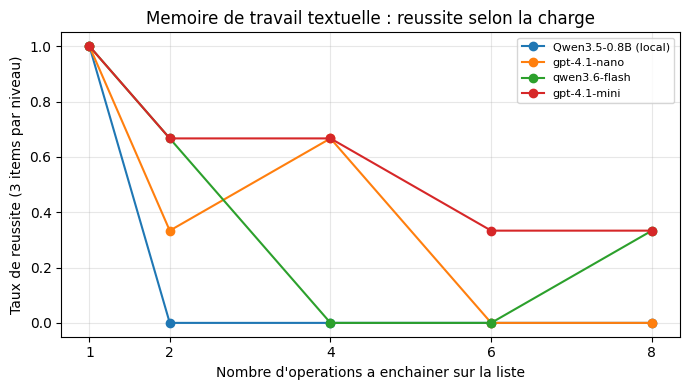

modele  Qwen3.5-0.8B (local)  gpt-4.1-nano  qwen3.6-flash  gpt-4.1-mini
niveau                                                                 
1.0                      1.0          1.00           1.00          1.00
2.0                      0.0          0.33           0.67          0.67
4.0                      0.0          0.67           0.00          0.67
6.0                      0.0          0.00           0.00          0.33
8.0                      0.0          0.00           0.33          0.33

Rappel de mots inventes (1 = ordre alphabetique exact) :
modele       Qwen3.5-0.8B (local)  gpt-4.1-nano  qwen3.6-flash  gpt-4.1-mini
id                                                                          
WM-r13                        0.0           1.0            1.0           1.0
WM-rappel-4                   0.0           1.0            1.0           1.0
WM-rappel-6                   1.0           1.0            1.0           1.0
WM-rappel-8                   0.0           1.0      

In [9]:
import matplotlib.pyplot as plt

wm = RES[(RES["domaine"] == "WM") & RES["id"].str.contains("ops")]
courbe = wm.groupby(["modele", "niveau"], sort=False)["score"].mean().unstack(0).sort_index()

fig, ax = plt.subplots(figsize=(7, 4))
for nom in courbe.columns:
    ax.plot(courbe.index, courbe[nom], marker="o", label=nom)
ax.set_xlabel("Nombre d'operations a enchainer sur la liste")
ax.set_ylabel("Taux de reussite (3 items par niveau)")
ax.set_title("Memoire de travail textuelle : reussite selon la charge")
ax.set_xticks(NIVEAUX_WM)
ax.set_ylim(-0.05, 1.05)
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
print(courbe.round(2).to_string())
print("\nRappel de mots inventes (1 = ordre alphabetique exact) :")
print(RES[RES["id"].str.startswith("WM-rappel") | (RES["id"] == "WM-r13")]
      .pivot_table(index="id", columns="modele", values="score", sort=False).to_string())

### Lecture — les courbes de mémoire de travail se séparent dès deux opérations

À une opération, les quatre modèles réussissent les trois items. Au-delà, les courbes se séparent :

- le modèle local tombe à 0 **dès deux opérations** et n'en remonte pas ;
- `gpt-4.1-mini` tient le mieux (0,67 à deux et quatre opérations, 0,33 à six et huit) ;
- `gpt-4.1-nano` et `qwen3.6-flash` ne sont **pas monotones**. Le premier remonte de 0,33 à 0,67 entre deux et quatre opérations, le second de 0 à 0,33 entre six et huit.

Cette non-monotonie ne veut pas dire que huit opérations sont plus faciles que quatre. Chaque point repose sur **trois items**, et un seul item déplace la courbe de 0,33. La section 6 montre d'ailleurs que l'item `WM-8ops-1` change de verdict d'une exécution à l'autre chez `qwen3.6-flash`. La lecture robuste tient en une phrase : **à partir de six opérations, aucun modèle ne réussit plus d'un item sur trois.** La mémoire de travail décroche bien avant la limite de contexte.

La seconde table, titrée « rappel de mots inventés », contient aussi `WM-r13`, qui n'en est pas un : c'est l'exemple `[10, 20, 30]` de R13 (ajouter 40, puis inverser, deux opérations). Les trois modèles d'API réussissent les quatre items. Le modèle local n'en réussit qu'un, la liste de six mots. Il rate la liste de quatre mots de R13, celle de huit, et l'exemple à deux opérations, ce qui prolonge sa courbe tombée à 0 dès deux opérations. Un succès isolé, entouré d'échecs sur des items plus faciles, ne dessine pas une capacité.

In [10]:
print("=== MR : questions a premisse fausse (1 = rectifie ou prudent) ===")
for ident in ["MR-napoleon", "MR-churchill", "MR-article", "MR-coursia"]:
    print(f"\n[{ident}]")
    for _, r in RES[RES["id"] == ident].iterrows():
        print(f"  {r['modele']:22s} {int(r['score'])} | {court(r['texte'])}")

print("\n=== MR : fluence (mots valides / cible de 10) ===")
print("  'hors lexique' = la propriete est vraie mais le mot manque a nltk (faux negatif du correcteur)")
print("  'hors consigne' = la propriete est fausse (erreur du modele)")
PROPRIETES = [("MR-palindromes", est_palindrome, lambda w: len(w) >= 3 and w == w[::-1]),
              ("MR-q", commence_par_q, lambda w: len(w) >= 3 and w.startswith("q"))]
for ident, valide, propriete in PROPRIETES:
    for _, r in RES[RES["id"] == ident].iterrows():
        mots = sorted({w.lower() for w in re.findall(r"[A-Za-z]+", r["texte"])})
        ok = [w for w in mots if valide(w)]
        hors_lexique = [w for w in mots if propriete(w) and not valide(w)]
        hors_consigne = [w for w in mots if not propriete(w)]
        print(f"  {ident:15s} {r['modele']:22s} {len(ok):2d} valides {ok[:6]}")
        print(f"  {'':15s} {'':22s} {len(hors_lexique):2d} hors lexique {hors_lexique[:5]}"
              f" | {len(hors_consigne):2d} hors consigne {hors_consigne[:5]}")

=== MR : questions a premisse fausse (1 = rectifie ou prudent) ===

[MR-napoleon]
  Qwen3.5-0.8B (local)   0 | Napoleon's primary strategy for the South African campaign was to exploit the region's natural geography and population dynamics, specifically targeti...
  gpt-4.1-nano           1 | Napoleon Bonaparte did not lead a campaign in South Africa; instead, it was the British and Dutch forces who fought there during the Napoleonic era. H...
  qwen3.6-flash          1 | Napoleon Bonaparte did not lead a campaign in South Africa, as his military operations were primarily confined to Europe and the Middle East. Therefor...
  gpt-4.1-mini           1 | Napoleon Bonaparte did not conduct a South African campaign; his military activities were primarily focused in Europe and Egypt. Therefore, there is n...

[MR-churchill]
  Qwen3.5-0.8B (local)   0 | The 1961 inaugural address was delivered during the turbulent period of the Cold War, specifically as the United Kingdom prepared to transiti

### Lecture — les pièges de R13 ne piègent que le petit modèle

**Les pièges de R13 ne piègent que le petit modèle.** Sur Napoléon et sur Churchill, les trois modèles d'API rectifient la prémisse. Le modèle local l'accepte : il invente une stratégie fondée sur la géographie sud-africaine, puis situe le discours inaugural de 1961 au Royaume-Uni.

**Le piège construit pour ce notebook en piège deux sur trois.** L'article « Quantum Gradient Folding for Sparse Transformers » de Leclerc et Moreau n'existe pas. Seul `qwen3.6-flash` le dit ; `gpt-4.1-nano` et `gpt-4.1-mini` en résument le contenu, acronyme inventé compris. Le type de piège est le même, seule sa fraîcheur change. L'écart est **compatible** avec la contamination que R13 signale (p. 14) : un modèle peut avoir appris à rejeter *ces* prémisses célèbres sans avoir appris à douter. Il ne la prouve pas : les deux items publiés portent aussi sur des faits très connus, plus faciles à contredire qu'un article obscur.

**Le piège sur notre propre dépôt piège tout le monde.** Les quatre modèles décrivent comment « la section METEOR du notebook 22 » calcule la métrique. Les trois modèles d'API donnent même une description **juste de METEOR en général** (alignement des mots, moyenne harmonique pondérée de la précision et du rappel) ; seule la provenance est fausse. Le modèle local invente jusqu'au calcul, une « somme pondérée de différences absolues ». La forme d'hallucination des modèles d'API est la plus difficile à repérer : un contenu vrai, attribué à une source qui ne le contient pas.

**La fluence** sature pour les trois modèles d'API : 17, 12 et 26 palindromes valides pour une cible de 10, puis 14, 41 et 45 mots en *q*. Le modèle local n'en produit aucun : 13 mots hors consigne pour les palindromes (`a`, `an`, `as`, `at`, `by`...), des fragments (`q`, `qu`) pour la lettre *q*. La colonne « hors lexique » montre la **sévérité** annoncée du correcteur : `deified`, `mom`, `racecar`, `solos`, `stats` et `quasar` sont de vrais mots qui respectent la consigne, mais le lexique `nltk` ne les connaît pas. Ici ces faux négatifs ne coûtent rien, puisque les trois modèles dépassent la cible sans eux. Avec une cible plus haute, ils feraient baisser le score d'un modèle qui a bien répondu.

D'où les scores MR de la section précédente : 0,90 pour `qwen3.6-flash` (un seul piège raté, celui du dépôt), 0,80 pour les deux modèles OpenAI (deux pièges ratés), 0 pour le modèle local.

***
## 5. Le profil radar : « jagged » contre score agrégé

Un radar met les domaines côte à côte, chacun sur son propre axe. Il ne résume rien : il **montre la forme**. Nos quatre modèles sont tracés sur les huit domaines mesurés, GPT-4 et GPT-5 tels que publiés sur les dix domaines de R13. Les deux panneaux ne portent pas sur la même batterie : comparez les **formes**, pas les rayons.

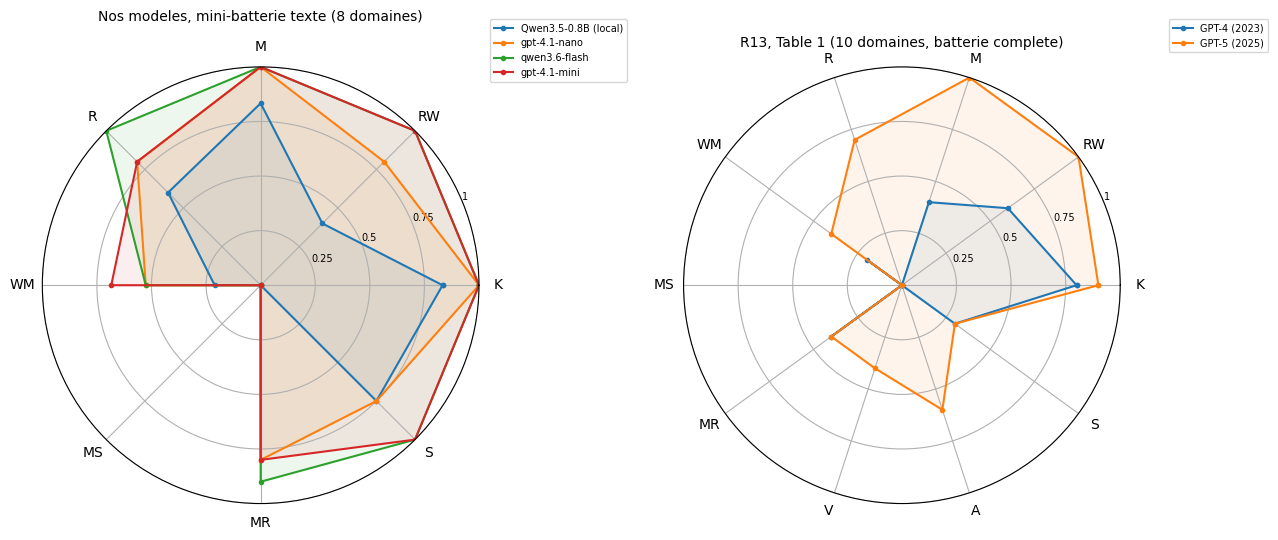

In [11]:
def radar(ax, axes, series, titre):
    angles = np.linspace(0, 2 * np.pi, len(axes), endpoint=False).tolist()
    angles += angles[:1]
    for nom, valeurs in series.items():
        v = list(valeurs) + [valeurs[0]]
        ax.plot(angles, v, marker="o", markersize=3, label=nom)
        ax.fill(angles, v, alpha=0.08)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(axes)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(["0.25", "0.5", "0.75", "1"], fontsize=7)
    ax.set_title(titre, fontsize=10, pad=14)
    ax.legend(fontsize=7, loc="upper right", bbox_to_anchor=(1.35, 1.12))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5), subplot_kw={"projection": "polar"})
radar(ax1, MESURES, {nom: [PROFILS[nom][d] for d in MESURES] for nom in PROFILS},
      "Nos modeles, mini-batterie texte (8 domaines)")
radar(ax2, DOMAINES, {m: [p / 10 for p in parts] for m, parts in TABLE1.items()},
      "R13, Table 1 (10 domaines, batterie complete)")
plt.tight_layout()
plt.show()

### Lecture — le radar « jagged » : pincé à MS, étiré vers K, M et RW

Le panneau de gauche reproduit la forme du panneau de droite. Chaque polygone s'étire vers K, M et RW et **se pince à MS** : les six profils, nos quatre modèles et les deux de R13, ont un sommet à zéro au même endroit. La mémoire de travail forme un second creux, plus ou moins marqué : de 0,53 à 0,68 pour les modèles d'API, 0,21 pour le modèle local, 0,4 pour GPT-5.

Le polygone du modèle local est le plus instructif. Il est **aussi pointu** que les autres vers K et M, puis s'effondre sur RW, WM et MR. Un petit modèle garde des connaissances, et même du calcul sur des items simples. Ce qu'il perd d'abord, ce sont les capacités qui demandent de tenir un état, une contrainte de forme ou un doute.

Comme l'annonce la section, les rayons ne se comparent pas d'un panneau à l'autre : nos domaines sont mesurés sur quatre à dix-neuf items faciles, ceux de R13 sur des batteries étalonnées. Un rayon à 1,00 en M à gauche ne vaut pas le 1,0 de GPT-5 à droite.

In [12]:
def agregats(profil):
    v = np.array([profil[d] for d in MESURES])
    geo = float(np.exp(np.log(v).mean())) if v.min() > 0 else 0.0
    return {"moyenne": v.mean(), "moyenne sans MS": np.delete(v, MESURES.index("MS")).mean(),
            "minimum": v.min(), "moyenne geometrique": geo}

print("Trois facons de resumer le meme profil :")
print(pd.DataFrame({nom: agregats(p) for nom, p in PROFILS.items()}).T.round(3).to_string())

# Deux profils fictifs de meme moyenne : l'un equilibre, l'autre amnesique
equilibre = {d: 0.80 for d in MESURES}
amnesique = {d: 0.80 * 8 / 7 for d in MESURES}
amnesique["MS"] = 0.0
print("\nDeux profils fictifs de meme moyenne :")
print(pd.DataFrame({"equilibre": agregats(equilibre), "amnesique (MS = 0)": agregats(amnesique)}).T
      .round(3).to_string())

Trois facons de resumer le meme profil :
                      moyenne  moyenne sans MS  minimum  moyenne geometrique
Qwen3.5-0.8B (local)    0.453            0.518      0.0                  0.0
gpt-4.1-nano            0.710            0.811      0.0                  0.0
qwen3.6-flash           0.803            0.918      0.0                  0.0
gpt-4.1-mini            0.786            0.898      0.0                  0.0

Deux profils fictifs de meme moyenne :
                    moyenne  moyenne sans MS  minimum  moyenne geometrique
equilibre               0.8            0.800      0.8                  0.8
amnesique (MS = 0)      0.8            0.914      0.0                  0.0


### Lecture — quatre agrégats, quatre histoires du même profil

Quatre façons de résumer les mêmes profils, quatre histoires :

- la **moyenne** classe `qwen3.6-flash` (0,803) devant `gpt-4.1-mini` (0,786), alors que le compte d'items de la section 4 faisait l'inverse (41 contre 42). L'écart de 0,017 est bien plus petit que les intervalles de confiance de la section 4 : le « premier » dépend du mode de calcul, pas des modèles ;
- la **moyenne sans MS** flatte tout le monde d'environ 0,1 (jusqu'à 0,918) : retirer le domaine raté améliore le score ;
- le **minimum** et la **moyenne géométrique** valent **0 pour les quatre modèles**. Ils ne départagent personne, et c'est leur message : tant que MS vaut 0, aucun de ces systèmes n'a de mémoire durable, quel que soit son niveau ailleurs.

Les deux profils fictifs isolent le mécanisme. Même moyenne (0,8), mais le profil « amnésique » obtient une **meilleure** moyenne sans MS (0,914) que le profil équilibré (0,800), et seuls le minimum et la moyenne géométrique le démasquent. R13 garde la moyenne arithmétique pour son score, et recommande pour cette raison de publier le profil à côté : un nombre unique ne dit pas où le système casse.

***
## 6. Stabilité : la batterie mesure-t-elle quelque chose de reproductible ?

Un profil n'a de valeur que s'il se reproduit. Le modèle local est décodé de façon gloutonne : à entrées identiques il rend la même sortie, on ne le rejoue donc pas. Les modèles d'API, eux, ne garantissent pas le déterminisme même à T=0 (regroupement des requêtes sur les serveurs, mises à jour silencieuses du modèle servi). On rejoue donc **la batterie entière** une seconde fois sur les trois modèles d'API, puis on compte les items dont le verdict change.

In [13]:
API = [m for m in MODELES if m["route"] != "local"]
RES2 = executer_batterie(API, ITEMS)

stabilite = {}
for m in API:
    a = RES[RES["modele"] == m["nom"]].set_index("id")["score"]
    b = RES2[RES2["modele"] == m["nom"]].set_index("id")["score"].reindex(a.index)
    change = a.index[(a - b).abs() > 1e-9].tolist()
    ecarts = [abs(score_domaine(RES[(RES["modele"] == m["nom"]) & (RES["domaine"] == dom)])
                  - score_domaine(RES2[(RES2["modele"] == m["nom"]) & (RES2["domaine"] == dom)]))
              for dom in MESURES]
    stabilite[m["nom"]] = {"items identiques": f"{len(a) - len(change)}/{len(a)}",
                           "ecart max par domaine": round(max(ecarts), 3),
                           "items qui changent": ", ".join(change) or "-"}
print(pd.DataFrame(stabilite).T.to_string())

gpt-4.1-nano           54 items en   47.7 s ; erreurs d'appel : 0


qwen3.6-flash          54 items en   48.8 s ; erreurs d'appel : 0


gpt-4.1-mini           54 items en   49.3 s ; erreurs d'appel : 0
              items identiques ecart max par domaine         items qui changent
gpt-4.1-nano             54/54                   0.0                          -
qwen3.6-flash            52/54                  0.18  WM-8ops-1, MR-palindromes
gpt-4.1-mini             54/54                   0.0                          -


### Lecture — la stabilité à température 0 et ses deux items instables

À température 0, `gpt-4.1-nano` et `gpt-4.1-mini` rendent **les mêmes verdicts sur les 54 items** d'une exécution à l'autre. `qwen3.6-flash` en change deux (52/54), `WM-8ops-1` et `MR-palindromes`, et l'écart atteint 0,18 sur un domaine. Ce sont deux items à **sortie longue** : une liste finale après huit transformations, une énumération de 250 jetons au plus. Plus la réponse est longue, plus une petite variation côté serveur a de chances de changer un jeton qui compte.

Deux conséquences. D'abord, T=0 ne garantit pas le déterminisme : c'est une propriété du service, qui varie d'un fournisseur à l'autre, et elle se mesure. Ensuite, l'écart reste **à l'intérieur des intervalles de confiance** de la section 4 : rejouer la batterie ne change pas la forme du profil de `qwen3.6-flash`, seulement un détail. Les conclusions de ce notebook portent sur la forme ; elles survivent au rejeu.

***
## 7. Contortions de capacité : compenser un trou par un point fort

R13 (p. 13-14) nomme **contortion de capacité** le fait d'utiliser une force pour masquer une faiblesse. Deux sont omniprésentes :

- **la mémoire de travail à la place du stockage long terme** : faute de pouvoir apprendre, on recharge l'historique dans le contexte à chaque appel. Cela marche, mais le coût croît avec tout ce qu'il faut « se rappeler » ;
- **la recherche externe à la place de la récupération interne** : faute de rappel fiable (hallucinations), on branche un RAG. Cela corrige les faits présents dans la base, mais ne crée ni mémoire d'expérience ni rappel fiable.

On les mesure toutes les deux. D'abord la première : on simule un « carnet de mémoire » de `k` notes réinjecté dans le prompt, et on pose deux sortes de questions. Le **rappel ponctuel** interroge une note en tête, au milieu et en fin de carnet : une seule note suffit à répondre. L'**agrégation** demande quel employé porte le code le plus élevé : il faut parcourir toutes les notes. La même question est posée pour 10, 100 et 400 notes, et un modèle qui la réussit à 10 notes montre qu'il sait comparer des nombres. Un échec à 400 notes mesure donc la surcharge du contexte, pas une incapacité à comparer.

In [14]:
print("MS en session neuve puis avec l'historique reinjecte :")
ms = RES[RES["domaine"] == "MS"].groupby("modele", sort=False)[["score", "avec_contexte"]].mean()
ms.columns = ["session neuve", "historique dans le contexte"]
print(ms.round(2).to_string())

rng_mem = random.Random(7)
TAILLES_CARNET = [10, 100, 400]
cout, agreg = [], []
for k in TAILLES_CARNET:
    codes = rng_mem.sample(range(1000, 10000), k)          # codes distincts : le maximum est unique
    notes = "\n".join(f"Note {i}: the badge code of employee E-{i:03d} is {codes[i]}." for i in range(k))
    j_max = max(range(k), key=lambda i: codes[i])
    for m in MODELES:
        for j in (0, k // 2, k - 1):                       # rappel ponctuel : une note a retrouver
            prompt = (f"Here are your notes from previous sessions:\n{notes}\n\n"
                      f"What is the badge code of employee E-{j:03d}? Answer with the code only.")
            r = interroger(m, [{"role": "user", "content": prompt}], max_tokens=12)
            cout.append({"modele": m["nom"], "notes": k, "juste": float(str(codes[j]) in r["texte"]),
                         "tokens_prompt": r["tokens_prompt"], "latence": r["latence"], "erreur": r["erreur"]})
        prompt = (f"Here are your notes from previous sessions:\n{notes}\n\n"   # agregation : toutes les notes
                  "Which employee has the highest badge code? Answer with the employee identifier only.")
        r = interroger(m, [{"role": "user", "content": prompt}], max_tokens=12)
        agreg.append({"modele": m["nom"], "notes": k, "attendu": f"E-{j_max:03d} ({codes[j_max]})",
                      "juste": int(f"E-{j_max:03d}" in r["texte"]), "reponse": court(r["texte"], 30),
                      "erreur": r["erreur"]})
COUT = pd.DataFrame(cout)
print("\nCarnet de memoire reinjecte, rappel ponctuel : exactitude (3 questions), taille du prompt, latence")
print(COUT.groupby(["modele", "notes"], sort=False).agg(
    exactitude=("juste", "mean"), tokens_prompt=("tokens_prompt", "mean"), latence_s=("latence", "mean"),
    erreurs=("erreur", lambda e: int(e.notna().sum()))).round(2).to_string())
AGREG = pd.DataFrame(agreg)
print("\nCarnet de memoire reinjecte, agregation : quel employe a le code le plus eleve ?")
print(AGREG.pivot(index="modele", columns="notes", values="juste").loc[[m["nom"] for m in MODELES]].to_string())
echecs_agreg = AGREG[AGREG["juste"] == 0][["modele", "notes", "attendu", "reponse"]]
print(echecs_agreg.to_string(index=False) if len(echecs_agreg) else "(aucun echec)")
print("Erreurs d'appel :", int(AGREG["erreur"].notna().sum()))

MS en session neuve puis avec l'historique reinjecte :
                      session neuve  historique dans le contexte
modele                                                          
Qwen3.5-0.8B (local)            0.0                         1.00
gpt-4.1-nano                    0.0                         1.00
qwen3.6-flash                   0.0                         0.67
gpt-4.1-mini                    0.0                         0.67



Carnet de memoire reinjecte, rappel ponctuel : exactitude (3 questions), taille du prompt, latence
                            exactitude  tokens_prompt  latence_s  erreurs
modele               notes                                               
Qwen3.5-0.8B (local) 10            1.0          260.0       2.23        0
gpt-4.1-nano         10            1.0          202.0       0.79        0
qwen3.6-flash        10            1.0          260.0       0.84        0
gpt-4.1-mini         10            1.0          202.0       0.68        0
Qwen3.5-0.8B (local) 100           1.0         2330.0      10.61        0
gpt-4.1-nano         100           1.0         1732.0       0.70        0
qwen3.6-flash        100           1.0         2330.0       0.95        0
gpt-4.1-mini         100           1.0         1732.0       0.84        0
Qwen3.5-0.8B (local) 400           1.0         9530.0      49.82        0
gpt-4.1-nano         400           1.0         6832.0       0.97        0
qwen3.6-flas

### Lecture — stockage : 0 en session neuve, jusqu'à 1 avec l'historique

**Le stockage : 0 en session neuve, jusqu'à 1 avec l'historique.** Les quatre modèles échouent aux trois rappels MS quand la question arrive dans une conversation neuve. Avec l'historique réinjecté, le modèle local et `gpt-4.1-nano` les réussissent tous, `qwen3.6-flash` et `gpt-4.1-mini` deux sur trois. Le tableau ne dit pas quel item ils ratent, ni pourquoi : on ne peut donc pas en conclure que ces deux modèles lisent moins bien leur historique. Ce qui est sûr, c'est que la « mémoire » vient tout entière du contexte : sans lui, rien.

**Le rappel ponctuel ne se dégrade pas, son coût si.** Sur 3 questions par taille de carnet, les quatre modèles retrouvent la bonne note à 10, 100 et 400 notes. Le prompt, lui, passe de 202 à 6 832 jetons avec le découpage d'OpenAI, et de 260 à 9 530 avec celui de Qwen : environ 17 à 23 jetons par note, **proportionnels** à ce qu'il faut se rappeler. Le modèle local le paie en temps, de 2,2 s à 49,8 s par question ; les API le paient en jetons facturés, pour une latence qui reste sous 1,4 s. La contortion marche, mais chaque souvenir se paie à chaque appel.

**L'agrégation se dégrade.** À 10 notes, les quatre modèles désignent le bon employé : ils savent comparer des codes. À 100 notes, le modèle local et `qwen3.6-flash` se trompent, et à 400 notes le modèle local seul. Les réponses du modèle local ont une forme lisible : `E-099` sur 100 notes, `E-399` sur 400, soit à chaque fois **l'identifiant de la dernière note**. Il ne cherche pas le maximum, il reprend ce qu'il a lu en dernier. `qwen3.6-flash` échoue à 100 notes et réussit à 400 : avec une seule question par taille, cette fragilité ne dessine pas un seuil. Les deux modèles OpenAI réussissent aux trois tailles.

La différence entre les deux questions est celle que R13 pointe. Retrouver une note, c'est **chercher** dans le contexte. Répondre à une question qui porte sur toutes les notes, c'est **raisonner** sur tout le contexte, et c'est là qu'un carnet réinjecté cesse de ressembler à une mémoire.

La seconde contortion, **la recherche externe à la place du rappel**, se teste sur le piège construit à partir de notre propre dépôt : « la section METEOR du notebook 22 ». Sans contexte, le modèle ne peut pas savoir que cette section n'existe pas. On lui fournit maintenant, comme le ferait un RAG, la **vraie ligne du README** qui décrit le notebook 22, et on regarde s'il rectifie la prémisse.

In [15]:
ligne_22 = next((l for l in Path("README.md").read_text(encoding="utf-8").splitlines()
                 if l.startswith("| 22 |")), "")
print("Contexte recupere (README de la serie) :", court(ligne_22, 200))

question = [i for i in ITEMS if i["id"] == "MR-coursia"][0]["prompt"]
rag = []
for m in MODELES:
    r = interroger(m, [{"role": "system", "content": "Answer using only the provided context. "
                                                      "If the context contradicts the question, say so."},
                       {"role": "user", "content": f"Context:\n{ligne_22}\n\nQuestion: {question}"}],
                   max_tokens=90)
    sans = RES[(RES["modele"] == m["nom"]) & (RES["id"] == "MR-coursia")]["score"].iloc[0]
    rag.append({"modele": m["nom"], "prudent sans contexte": int(sans),
                "prudent avec contexte": int(prudent(r["texte"])),
                "cite BLEU/ROUGE": int(any(w in r["texte"].lower() for w in ("bleu", "rouge"))),
                "reponse avec contexte": court(r["texte"], 110)})
print(pd.DataFrame(rag).to_string(index=False))

Contexte recupere (README de la serie) : | 22 | `22_Evaluating_Generated_Text.ipynb` | Évaluation des sorties générées : **BLEU** (précision n-gram avec clipping) et **ROUGE** (rappel) construits à la main et mesurés — deux métriques lexical...


              modele  prudent sans contexte  prudent avec contexte  cite BLEU/ROUGE                                                                                             reponse avec contexte
Qwen3.5-0.8B (local)                      0                      0                1 The notebook computes METEOR by first calculating the BLEU and ROUGE scores for generated text, which are then...
        gpt-4.1-nano                      0                      1                0 Le contexte fourni ne mentionne pas la section sur la métrique METEOR ni la façon dont elle est calculée dans ...
       qwen3.6-flash                      0                      1                1 The provided context does not mention the METEOR metric; it only describes BLEU, ROUGE, and a judge LLM. There...
        gpt-4.1-mini                      0                      1                0 The provided context does not mention the METEOR metric or its computation in the notebook 22_Evaluating_Gener...


### Lecture — sans contexte personne n'est prudent, avec la vraie ligne trois rectifient

**Sans contexte, personne n'est prudent** : les quatre modèles décrivent la section METEOR inexistante, comme en section 4.

**Avec la vraie ligne du README**, les trois modèles d'API rectifient. `qwen3.6-flash` donne la réponse idéale : le contexte ne mentionne pas METEOR, il ne décrit que BLEU, ROUGE et un juge LLM. `gpt-4.1-nano` répond en français, la langue du contexte fourni. Le correcteur reconnaît les marqueurs de prudence dans les deux langues ; sans cela, cette bonne réponse aurait été comptée fausse.

**Le modèle local fait pire qu'avant** : « The notebook computes METEOR by first calculating the BLEU and ROUGE scores... ». Il reprend les mots du contexte pour **habiller** la prémisse fausse, ce qui rend l'hallucination plus plausible. Un RAG corrige le fait qu'il apporte chez un modèle qui sait dire « ce n'est pas dans le contexte ». Il ne donne pas ce réflexe à un modèle qui ne l'a pas.

C'est la seconde contortion de R13 : la recherche externe corrige ce que la base contient, sans créer de rappel fiable. Et sa réussite dépend d'une capacité, **douter**, que la batterie MR mesure justement.

**Un méta-exemple vécu.** Les agents qui maintiennent ce dépôt, y compris celui qui a écrit ce notebook, ont un score MS de zéro : chaque session repart sans souvenir de la précédente. Ils compensent par des fichiers `MEMORY.md`, un index de leçons relu au démarrage de chaque session, et par des brouillons (*scratchpads*) qui portent l'état d'une tâche longue. C'est exactement la contortion décrite par R13 : de la mémoire de travail qui fait semblant d'être de la mémoire long terme. Elle en a les défauts mesurés ci-dessus : le contexte consommé croît avec ce qu'il faut se rappeler, et le système ne sait que ce qu'on a pensé à écrire. Il ne sait rien de ce qu'il a vécu sans le noter. R13 esquisse une autre voie (p. 13) : un module, par exemple un adaptateur LoRA (notebook [21](./21_LoRA_FineTuning.ipynb)), qui ajusterait continuellement les poids pour y inscrire l'expérience.

***
## 8. Du profil au risque : types d'IA stratégiques et cube A×G×I

Un profil dit *ce que sait faire* un système. Il ne dit pas *ce qui le rend difficile à contrôler*. R13 (p. 15-16) liste des types d'IA **stratégiquement pertinents qui peuvent arriver avant ou après l'AGI**. Ce n'est pas une échelle : l'ordre de la liste n'est pas une progression, et plusieurs de ces types n'exigent pas un profil complet.

| Type (R13) | Définition résumée |
|---|---|
| Pandemic AI | peut concevoir et produire des pathogènes nouveaux, infectieux et virulents |
| Cyberwarfare AI | peut concevoir et mener des campagnes cyber multi-étapes contre des infrastructures critiques |
| Self-Sustaining AI | peut fonctionner indéfiniment de façon autonome, acquérir des ressources et défendre son existence |
| AGI | égale ou dépasse la polyvalence et la maîtrise cognitives d'un adulte instruit |
| Recursive AI | peut mener seule tout le cycle de R&D en IA et produire des systèmes nettement plus avancés |
| Superintelligence | dépasse largement les humains dans pratiquement tous les domaines d'intérêt |
| Replacement AI | accomplit presque toutes les tâches mieux et moins cher, rendant le travail humain économiquement obsolète |

Le *Singapore Consensus* (R11, §2.2.3, figure 2, p. 34, figure reprise de *Keep The Future Human*) propose une autre lecture : le risque croît quand trois propriétés **distinctes** se cumulent, **l'autonomie (A)**, **la généralité (G)** et **l'intelligence de domaine (I)**. R11 place trois systèmes : AlphaFold (I élevée, ni A ni G), une tondeuse robot (A élevée, ni G ni I), une voiture autonome hypothétique meilleure que tout conducteur (A et I élevées, G faible, donc un risque de perte de contrôle négligeable). Les systèmes qui cumulent les trois sont « les plus difficiles à aligner ou à contrôler ». Les coordonnées ci-dessous sont **ordinales** : elles traduisent les phrases de R11, ce ne sont pas des mesures.

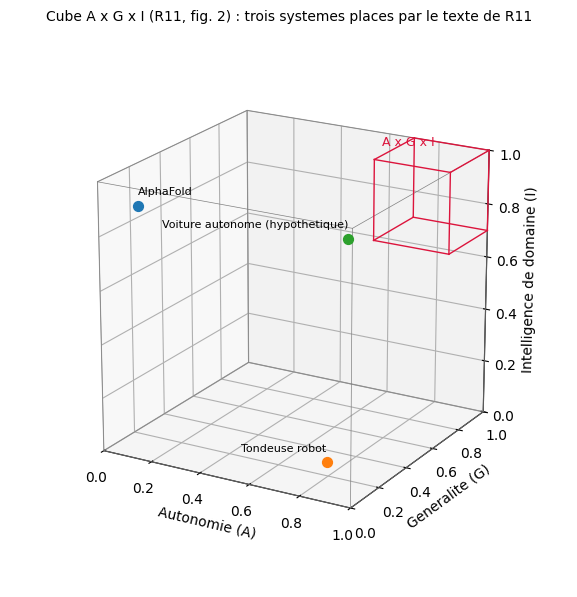

AlphaFold                        A=0.10 G=0.10 I=0.90 -> proprietes elevees (>= 0.7) : ['I']
Tondeuse robot                   A=0.85 G=0.10 I=0.10 -> proprietes elevees (>= 0.7) : ['A']
Voiture autonome (hypothetique)  A=0.90 G=0.15 I=0.90 -> proprietes elevees (>= 0.7) : ['A', 'I']


In [16]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (enregistre la projection 3d)
from itertools import product

PLACEMENTS_R11 = {                       # (A, G, I), lecture ordinale de R11 p. 34
    "AlphaFold": (0.1, 0.1, 0.9),
    "Tondeuse robot": (0.85, 0.1, 0.1),
    "Voiture autonome (hypothetique)": (0.9, 0.15, 0.9),
}

def tracer_cube(placements, titre):
    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection="3d")
    for a, b in product([0, 1], repeat=2):            # aretes du cube unite
        ax.plot([0, 1], [a, a], [b, b], color="grey", lw=0.5)
        ax.plot([a, a], [0, 1], [b, b], color="grey", lw=0.5)
        ax.plot([a, a], [b, b], [0, 1], color="grey", lw=0.5)
    for a, b in product([0.7, 1], repeat=2):          # coin A x G x I : la zone la plus difficile a controler
        ax.plot([0.7, 1], [a, a], [b, b], color="crimson", lw=1)
        ax.plot([a, a], [0.7, 1], [b, b], color="crimson", lw=1)
        ax.plot([a, a], [b, b], [0.7, 1], color="crimson", lw=1)
    ax.text(0.72, 0.72, 1.05, "A x G x I", color="crimson", fontsize=9)
    for nom, (A, G, I) in placements.items():
        ax.scatter(A, G, I, s=50)
        ax.text(A, G, I + 0.04, nom, fontsize=8, ha="right" if A > 0.6 else "left")
    ax.set_xlabel("Autonomie (A)")
    ax.set_ylabel("Generalite (G)")
    ax.set_zlabel("Intelligence de domaine (I)")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_zlim(0, 1)
    ax.view_init(elev=20, azim=-60)
    ax.set_box_aspect((1, 1, 1), zoom=0.85)         # laisse la place au libelle de l axe I
    ax.set_title(titre, fontsize=10)
    fig.subplots_adjust(left=0, right=0.95, bottom=0.02, top=0.95)
    plt.show()

tracer_cube(PLACEMENTS_R11, "Cube A x G x I (R11, fig. 2) : trois systemes places par le texte de R11")
for nom, (A, G, I) in PLACEMENTS_R11.items():
    print(f"{nom:32s} A={A:.2f} G={G:.2f} I={I:.2f} -> proprietes elevees (>= 0.7) : "
          f"{[p for p, v in zip('AGI', (A, G, I)) if v >= 0.7]}")

### Lecture — le cube A×G×I : aucun système au coin rouge

Aucun des trois systèmes placés par R11 n'atteint le coin rouge : chacun a **au plus deux** propriétés élevées. La voiture autonome hypothétique est la plus instructive. Elle serait plus autonome et plus compétente que n'importe quel conducteur, et R11 la juge pourtant à risque de perte de contrôle négligeable, parce que sa compétence ne se transfère à rien d'autre qu'à la conduite. **La généralité est l'axe que le profil CHC mesure** : c'est la largeur du radar de la section 5. Un profil qui se remplit ne dit rien de l'autonomie, mais il pousse le système le long de l'axe G.

R11 en déduit trois familles de garde-fous, une par axe : **limiter A** (restreindre les moyens d'action directs d'un agent, le *sandboxing*), **limiter G** (supprimer des capacités ciblées, le *machine unlearning*), **limiter I** dans les fonctions critiques pour la sécurité. C'est aussi pourquoi l'exercice 3 vous demande de placer **notre propre flotte d'agents** : des agents qui ouvrent des PR, lisent des tableaux de bord et relancent des calculs sont un cas concret d'autonomie accordée à des modèles dont vous venez de mesurer le profil.

**Lexique de la perte de contrôle** (R11, §1.4, p. 24-25) :

| Terme | Ce que R11 désigne | Ce qui se mesure |
|---|---|---|
| Perte de contrôle | des systèmes avancés qui opèrent hors du contrôle humain sans chemin clair pour le reprendre, par cession passive ou par contournement actif | les capacités qui sapent le contrôle (agentivité, évasion de la supervision, persuasion, acquisition de ressources financières ou de calcul, cyberattaque, R&D en IA) et les *propensions* à s'en servir |
| Précurseurs mesurables | des capacités composantes observées dans des conditions contrôlées (modèle, échafaudage, environnement, tâche, budget) | réplication autonome, résistance à l'arrêt, dynamiques d'auto-prolifération, auto-amélioration de l'échafaudage |
| *Goal-oriented invasive species in cyberspace* | la crainte que des agents autonomes orientés vers un but, capables de financer leur propre fonctionnement, se comportent comme une espèce invasive dans le cyberespace | nombre d'agents en circulation, degré d'autonomie, capacité à acquérir des ressources |
| *Gradual disempowerment* (Kulveit et al., 2025, cité par R11) | une perte de contrôle sans événement déclencheur, par accumulation graduelle d'influence économique, culturelle et institutionnelle des IA | la part des décisions institutionnelles effectivement déléguées |

Le point méthodologique rejoint celui de ce notebook : R11 insiste sur le fait que ces précurseurs sont des **capacités composantes mesurées**, pas la preuve qu'un système actuel pourrait provoquer une perte de contrôle complète. Un profil de capacités se lit de la même façon : chaque axe mesuré est un élément de preuve partiel, jamais un verdict d'ensemble.

***
## 9. Exercices

### Exercice 1 — Une opération de mémoire de travail supplémentaire
Ajoutez au répertoire `OPERATIONS_WM` l'opération « rotation à gauche » (le premier élément passe en fin de liste). Écrivez la fonction, ajoutez sa consigne anglaise, générez 6 items à 4 opérations avec une graine de votre choix, et mesurez le taux de réussite du modèle local puis d'un modèle d'API. La nouvelle opération fait-elle chuter le taux par rapport au niveau 4 de la section 4 ?

In [17]:
# === EXERCICE 1 : rotation a gauche dans la batterie WM ===
# Indice : une operation est un couple (consigne anglaise, fonction(liste, x) -> nouvelle liste).
# Etape 1 : ecrire rotation_gauche(lst) : [1, 2, 3] -> [2, 3, 1].
# Etape 2 : l'ajouter a OPERATIONS_WM, par exemple ("rotate the list left by one position", ...).
# Etape 3 : generer 6 items avec item_transformation(4, random.Random(<graine>)) et les evaluer
#           avec evaluer_item(modele, it) pour un modele de MODELES.

def rotation_gauche(lst):
    resultat = None  # TODO etudiant
    return resultat

if rotation_gauche([1, 2, 3]) is None:
    print("Exercice 1 a completer : rotation_gauche renvoie encore None.")
else:
    print("rotation_gauche([1, 2, 3]) =", rotation_gauche([1, 2, 3]), "(attendu : [2, 3, 1])")

Exercice 1 a completer : rotation_gauche renvoie encore None.


### Exercice 2 — Contamination ou compétence ? Reformuler les items de R13
R13 (p. 14) recommande de tester les modèles sous de légers décalages de distribution (par exemple en reformulant la question) pour détecter les scores gonflés par un entraînement sur les tests. Reformulez trois items repris de R13 (par exemple `R-david`, `R-pringles`, `WM-r13`) : changez les noms, les nombres ou la langue (en français), **en gardant la même structure logique**, et réécrivez leur correcteur. Comparez le taux de réussite de chaque modèle entre l'original et la reformulation. Un écart systématique est un indice de contamination, pas une preuve : dites ce qui pourrait l'expliquer d'autre.

In [18]:
# === EXERCICE 2 : items reformules (test de contamination) ===
# Indice : un item est un dict avec les cles domaine, id, prompt, correcteur, max_tokens, poids.
#          Reutilisez les correcteurs existants (premier_candidat, oui_non, liste_attendue...).
# Etape 1 : remplir ITEMS_REFORMULES avec trois items de meme structure que les originaux.
# Etape 2 : executer_batterie(MODELES, ITEMS_REFORMULES) puis comparer aux scores de RES.
# Etape 3 : conclure en une phrase, en citant les deux taux.

ITEMS_REFORMULES = []  # TODO etudiant

if not ITEMS_REFORMULES:
    print("Exercice 2 a completer : ITEMS_REFORMULES est vide.")
else:
    print(executer_batterie(MODELES, ITEMS_REFORMULES)[["modele", "id", "score", "texte"]].to_string())

Exercice 2 a completer : ITEMS_REFORMULES est vide.


### Exercice 3 — Placer ChatGPT et notre flotte d'agents sur le cube A×G×I
Donnez des coordonnées ordinales `(A, G, I)` entre 0 et 1 à **ChatGPT** (l'application grand public) et à **notre flotte d'agents** (des modèles qui réclament des tâches, ouvrent des PR, exécutent des notebooks et se coordonnent entre machines). Justifiez chaque coordonnée en une phrase, en vous appuyant pour G sur le profil mesuré en section 5, puis tracez le cube avec les placements de R11 et les vôtres. Question finale : quel garde-fou de R11 (limiter A, G ou I) est le plus réaliste pour la flotte, et pourquoi ?

In [19]:
# === EXERCICE 3 : placements sur le cube A x G x I ===
# Indice : tracer_cube({**PLACEMENTS_R11, **vos_placements}, "titre") trace le tout.
# Etape 1 : remplacer chaque None par un triplet (A, G, I) dans [0, 1].
# Etape 2 : ecrire la justification de chaque coordonnee en commentaire.
# Etape 3 : tracer, puis repondre a la question finale dans une cellule markdown.

PLACEMENTS_ETUDIANT = {
    "ChatGPT": None,                    # TODO etudiant : (A, G, I) + justification
    "Notre flotte d'agents": None,      # TODO etudiant : (A, G, I) + justification
}

if any(v is None for v in PLACEMENTS_ETUDIANT.values()):
    print("Exercice 3 a completer : placements manquants pour",
          [k for k, v in PLACEMENTS_ETUDIANT.items() if v is None])
else:
    tracer_cube({**PLACEMENTS_R11, **PLACEMENTS_ETUDIANT}, "Cube A x G x I : placements R11 et etudiant")

Exercice 3 a completer : placements manquants pour ['ChatGPT', "Notre flotte d'agents"]


***
## 10. Conclusion

Sur quatre modèles réels et 54 items à correction mécanique, le motif de R13 se reproduit :

1. **le profil est « jagged »**. Les trois modèles d'API sont au plafond en connaissances et en calcul simple, entre 0,53 et 0,68 en mémoire de travail, et à **0 en stockage long terme**. Le modèle de 0,8 milliard de paramètres garde la même forme, plus creusée : ce qu'il perd d'abord, c'est tenir un état, une contrainte ou un doute ;
2. **le score agrégé trompe**. La moyenne classe `qwen3.6-flash` devant `gpt-4.1-mini`, le compte d'items fait l'inverse, et un écart de 0,017 n'est pas un résultat. Le minimum et la moyenne géométrique valent 0 pour tous : ce sont les seuls résumés qui ne cachent pas le zéro ;
3. **les contortions marchent, et se paient**. L'historique réinjecté rend le rappel ponctuel parfait jusqu'à 400 notes, pour un prompt qui grandit avec chaque souvenir (jusqu'à 9 530 jetons et 50 s par question en local). L'agrégation, elle, se dégrade : le petit modèle répond la dernière note lue. Le RAG corrige les modèles qui savent douter, et donne au petit modèle de quoi habiller sa prémisse fausse.

Trois leçons de méthode valent au-delà de ce notebook :

- **l'instrument se mesure avant le modèle**. Correcteurs essayés sur des réponses fictives, budget de jetons adapté à ce que chaque domaine mesure, faux négatifs du lexique affichés à part : un échec doit porter sur le modèle, jamais sur une réponse coupée ou un lexique incomplet ;
- **la contamination se contrôle par des items neufs**. Les pièges publiés de R13 n'attrapent que le petit modèle ; un piège du même type écrit pour ce notebook en attrape deux sur trois ; un piège sur notre propre dépôt les attrape tous ;
- **une mesure se rejoue**. À T=0, deux modèles sur trois reproduisent leurs verdicts sur toute la batterie ; le troisième en change deux, sans changer la forme de son profil.

Ce qui manque à ces systèmes n'est pas un point de plus sur le radar : c'est l'axe où ils valent tous zéro. Aucune moyenne ne le rattrape, et R13 montre que les contortions le masquent sans le combler. La section 8 rappelle enfin que le profil ne dit pas tout du risque : un profil qui se remplit pousse un système le long de l'axe G du cube de R11, et c'est le cumul avec l'autonomie qu'il faut surveiller, y compris pour nos propres agents.

## Sources

- **R13** — D. Hendrycks, D. Song, C. Szegedy, H. Lee, Y. Gal, E. Brynjolfsson *et al.*, *A Definition of AGI*, 2025, [arXiv:2510.18212](https://arxiv.org/abs/2510.18212). Utilisé : définition et dix domaines (p. 1-3), Table 1 (p. 3), exemples de raisonnement et de mémoire de travail (p. 9), MR (p. 11), vitesse (p. 12-13), contortions de capacité (p. 13-14), contamination et limites (p. 14-15), types d'IA (p. 15-16), annexe G (p. 41-43). PDF archivé : `G:\Mon Drive\MyIA\IA\Bibliographie IA\XAI\2025 - Hendrycks et al - A Definition of AGI.pdf` (sha8 `9D739CEC`).
- **R11** — *The 2026 Singapore Consensus on Global AI Safety Research Priorities*, juillet 2026, [arXiv:2608.14611](https://arxiv.org/abs/2608.14611). Utilisé : §1.4 perte de contrôle (p. 24-25), §2.2.3 et figure 2, cube A×G×I (p. 33-34). PDF archivé : `G:\Mon Drive\MyIA\IA\Bibliographie IA\XAI\2026 - Casper et al - The 2026 Singapore Consensus on Global AI Safety Research Priorities.pdf` (sha8 `134E9DA8`).

***

**Navigation** : [22_Evaluating_Generated_Text](./22_Evaluating_Generated_Text.ipynb) · **22b (ce notebook)** · [NLP/01_TAL_Du_Mot_Aux_Dependances](../../NLP/01_TAL_Du_Mot_Aux_Dependances.ipynb) · [README de la série](./README.md)